In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy import stats
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

tf.random.set_seed(42)
np.random.seed(42)

# ── LOAD DATA ─────────────────────────────────────────────────────
data_path = r"J:\Research\Research\database\Diabetes_Dataset.xlsx"
df = pd.read_excel(data_path, sheet_name='Data1')
print(f"Dataset loaded: {df.shape}")

# ── VARIABLES ─────────────────────────────────────────────────────
target = 'X1'
predictors = [
    'Y1','Y2','Y3','Y5','Y6','Y7','Y8','Y9','Y10','Y11',
    'Y12','Y13','Y14','Y15','Y17','Y18','Y20','Y21','Y22','Y23',
]

X_all = df[predictors].copy()
y_all = df[target].copy()
year_col = df['Year'] if 'Year' in df.columns else df.iloc[:, 0]

mask = y_all.notna()
X_all = X_all[mask].reset_index(drop=True)
y_all = y_all[mask].reset_index(drop=True)
year_all = year_col[mask].reset_index(drop=True)
X_all = X_all.fillna(X_all.median())

# ── TEMPORAL SPLIT: 1990-2017 train, 2018-2022 test ───────────────
train_mask = year_all <= 2017
test_mask  = year_all >= 2018

X_train = X_all[train_mask].reset_index(drop=True)
X_test  = X_all[test_mask].reset_index(drop=True)
y_train = y_all[train_mask].reset_index(drop=True)
y_test  = y_all[test_mask].reset_index(drop=True)

print(f"Train (1990-2017): {X_train.shape[0]} rows")
print(f"Test  (2018-2022): {X_test.shape[0]} rows")

# Scale for DL
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_sc = scaler_X.fit_transform(X_train)
X_test_sc  = scaler_X.transform(X_test)
y_train_sc = scaler_y.fit_transform(y_train.values.reshape(-1,1)).ravel()
y_test_sc  = scaler_y.transform(y_test.values.reshape(-1,1)).ravel()

# ── METRICS ───────────────────────────────────────────────────────
def mape(y_true, y_pred):
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def compute_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mp   = mape(np.array(y_true), np.array(y_pred))
    return rmse, mae, mp

def bootstrap_ci(y_true, y_pred, n_boot=1000, ci=95):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    n = len(y_true)
    boot_rmse, boot_mae, boot_mape = [], [], []
    for _ in range(n_boot):
        idx = np.random.choice(n, n, replace=True)
        r, m, mp = compute_metrics(y_true[idx], y_pred[idx])
        boot_rmse.append(r); boot_mae.append(m); boot_mape.append(mp)
    alpha = (100 - ci) / 2
    return {
        'RMSE': (np.percentile(boot_rmse, alpha), np.percentile(boot_rmse, 100-alpha)),
        'MAE' : (np.percentile(boot_mae,  alpha), np.percentile(boot_mae,  100-alpha)),
        'MAPE': (np.percentile(boot_mape, alpha), np.percentile(boot_mape, 100-alpha)),
    }

def format_val_ci(val, lo, hi, decimals=3):
    fmt = f"{{:.{decimals}f}}"
    return f"{fmt.format(val)} ({fmt.format(lo)}, {fmt.format(hi)})"

# ── ML MODELS ─────────────────────────────────────────────────────
ml_models = {
    'XGBoost': XGBRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
        reg_alpha=0.1, reg_lambda=1.0, random_state=42, verbosity=0, n_jobs=1,
    ),
    'Random Forest': RandomForestRegressor(
        n_estimators=500, max_depth=10, min_samples_leaf=5,
        max_features='sqrt', random_state=42, n_jobs=1,
    ),
    'LightGBM': LGBMRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8, min_child_samples=10,
        reg_alpha=0.1, reg_lambda=1.0, random_state=42, verbose=-1, n_jobs=1,
    ),
}

# ── DL MODEL BUILDERS ─────────────────────────────────────────────
n_features = X_train_sc.shape[1]

def build_mlp():
    m = keras.Sequential([
        layers.Input(shape=(n_features,)),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.Dense(1),
    ])
    m.compile(optimizer=keras.optimizers.Adam(0.001), loss='mse')
    return m

def build_cnn():
    m = keras.Sequential([
        layers.Input(shape=(n_features, 1)),
        layers.Conv1D(64, kernel_size=3, activation='relu', padding='same'),
        layers.MaxPooling1D(pool_size=2),
        layers.Conv1D(32, kernel_size=3, activation='relu', padding='same'),
        layers.GlobalAveragePooling1D(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(1),
    ])
    m.compile(optimizer=keras.optimizers.Adam(0.001), loss='mse')
    return m

def build_lstm():
    m = keras.Sequential([
        layers.Input(shape=(n_features, 1)),
        layers.LSTM(64, return_sequences=True),
        layers.Dropout(0.2),
        layers.LSTM(32),
        layers.Dense(32, activation='relu'),
        layers.Dense(1),
    ])
    m.compile(optimizer=keras.optimizers.Adam(0.001), loss='mse')
    return m

dl_builders = {
    'MLP' : build_mlp,
    'CNN' : build_cnn,
    'LSTM': build_lstm,
}

# ── 5-FOLD CV ON TRAIN ────────────────────────────────────────────
print("\nRunning 5-Fold CV on training set...")
kf = KFold(n_splits=5, shuffle=True, random_state=42)

all_results = {}

# ML CV
for name, model in ml_models.items():
    print(f"  CV: {name}...")
    fold_preds = np.zeros(len(y_train))
    for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train)):
        model.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
        fold_preds[val_idx] = model.predict(X_train.iloc[val_idx])
    cv_rmse, cv_mae, cv_mape = compute_metrics(y_train.values, fold_preds)
    cv_ci = bootstrap_ci(y_train.values, fold_preds)
    
    # Test
    model.fit(X_train, y_train)
    y_pred_test = model.predict(X_test)
    ts_rmse, ts_mae, ts_mape = compute_metrics(y_test.values, y_pred_test)
    ts_ci = bootstrap_ci(y_test.values, y_pred_test)
    
    all_results[name] = {
        'type': 'ML',
        'cv_rmse': cv_rmse, 'cv_rmse_ci': cv_ci['RMSE'],
        'cv_mae' : cv_mae,  'cv_mae_ci' : cv_ci['MAE'],
        'cv_mape': cv_mape, 'cv_mape_ci': cv_ci['MAPE'],
        'ts_rmse': ts_rmse, 'ts_rmse_ci': ts_ci['RMSE'],
        'ts_mae' : ts_mae,  'ts_mae_ci' : ts_ci['MAE'],
        'ts_mape': ts_mape, 'ts_mape_ci': ts_ci['MAPE'],
    }
    print(f"    CV  RMSE={cv_rmse:.3f}  MAE={cv_mae:.3f}  MAPE={cv_mape:.2f}%")
    print(f"    Test RMSE={ts_rmse:.3f} MAE={ts_mae:.3f}  MAPE={ts_mape:.2f}%")

# DL CV
early_stop = keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True, verbose=0)

for name, builder in dl_builders.items():
    print(f"  CV: {name}...")
    is_seq = name in ('CNN', 'LSTM')
    
    X_tr_use = X_train_sc[:, :, np.newaxis] if is_seq else X_train_sc
    X_ts_use = X_test_sc[:, :, np.newaxis]  if is_seq else X_test_sc
    
    fold_preds_sc = np.zeros(len(y_train_sc))
    for fold, (tr_idx, val_idx) in enumerate(kf.split(X_tr_use)):
        tf.random.set_seed(fold)
        m = builder()
        m.fit(
            X_tr_use[tr_idx], y_train_sc[tr_idx],
            validation_data=(X_tr_use[val_idx], y_train_sc[val_idx]),
            epochs=200, batch_size=64, callbacks=[early_stop], verbose=0,
        )
        fold_preds_sc[val_idx] = m.predict(X_tr_use[val_idx], verbose=0).ravel()
    
    fold_preds = scaler_y.inverse_transform(fold_preds_sc.reshape(-1,1)).ravel()
    cv_rmse, cv_mae, cv_mape = compute_metrics(y_train.values, fold_preds)
    cv_ci = bootstrap_ci(y_train.values, fold_preds)
    
    # Final test
    tf.random.set_seed(42)
    m_final = builder()
    m_final.fit(
        X_tr_use, y_train_sc,
        epochs=300, batch_size=64, callbacks=[early_stop],
        validation_split=0.1, verbose=0,
    )
    y_pred_sc = m_final.predict(X_ts_use, verbose=0).ravel()
    y_pred_test = scaler_y.inverse_transform(y_pred_sc.reshape(-1,1)).ravel()
    ts_rmse, ts_mae, ts_mape = compute_metrics(y_test.values, y_pred_test)
    ts_ci = bootstrap_ci(y_test.values, y_pred_test)
    
    all_results[name] = {
        'type': 'DL',
        'cv_rmse': cv_rmse, 'cv_rmse_ci': cv_ci['RMSE'],
        'cv_mae' : cv_mae,  'cv_mae_ci' : cv_ci['MAE'],
        'cv_mape': cv_mape, 'cv_mape_ci': cv_ci['MAPE'],
        'ts_rmse': ts_rmse, 'ts_rmse_ci': ts_ci['RMSE'],
        'ts_mae' : ts_mae,  'ts_mae_ci' : ts_ci['MAE'],
        'ts_mape': ts_mape, 'ts_mape_ci': ts_ci['MAPE'],
    }
    print(f"    CV  RMSE={cv_rmse:.3f}  MAE={cv_mae:.3f}  MAPE={cv_mape:.2f}%")
    print(f"    Test RMSE={ts_rmse:.3f} MAE={ts_mae:.3f}  MAPE={ts_mape:.2f}%")

# ── SAVE TO EXCEL ─────────────────────────────────────────────────
print("\nSaving Excel...")

wb = openpyxl.Workbook()
ws = wb.active
ws.title = "Model Comparison"

# Styles
header_font   = Font(name='Arial', bold=True, size=11, color='FFFFFF')
subhdr_font   = Font(name='Arial', bold=True, size=10, color='FFFFFF')
cell_font     = Font(name='Arial', size=10)
best_font     = Font(name='Arial', size=10, bold=True, color='1F3864')

blue_fill   = PatternFill('solid', start_color='1F4E79')
ltblue_fill = PatternFill('solid', start_color='2E75B6')
green_fill  = PatternFill('solid', start_color='375623')
ltgreen_fill= PatternFill('solid', start_color='538135')
best_fill   = PatternFill('solid', start_color='DDEBF7')
alt_fill    = PatternFill('solid', start_color='F2F7FC')
white_fill  = PatternFill('solid', start_color='FFFFFF')

center = Alignment(horizontal='center', vertical='center', wrap_text=True)
left   = Alignment(horizontal='left',   vertical='center', wrap_text=False)

thin = Side(style='thin', color='BFBFBF')
med  = Side(style='medium', color='1F4E79')
border_all = Border(left=thin, right=thin, top=thin, bottom=thin)
border_med = Border(left=med,  right=med,  top=med,  bottom=med)

def style(cell, font=None, fill=None, align=None, border=None):
    if font:   cell.font      = font
    if fill:   cell.fill      = fill
    if align:  cell.alignment = align
    if border: cell.border    = border

# ── TITLE ROW ─────────────────────────────────────────────────────
ws.merge_cells('A1:G1')
ws['A1'] = 'Model Performance Comparison — Temporal Validation (Train: 1990–2017 | Test: 2018–2022)'
style(ws['A1'], Font(name='Arial', bold=True, size=13, color='FFFFFF'), blue_fill, center)
ws.row_dimensions[1].height = 28

ws.merge_cells('A2:G2')
ws['A2'] = f'5-Fold Cross-Validation on Training Set  |  Holdout Test Set  |  Values: Metric (95% CI)'
style(ws['A2'], Font(name='Arial', italic=True, size=9, color='FFFFFF'), ltblue_fill, center)
ws.row_dimensions[2].height = 18

# ── HEADER ROW 3: column labels ────────────────────────────────────
headers = ['Model', 'Type',
           'CV RMSE (95% CI)', 'CV MAE (95% CI)', 'CV MAPE % (95% CI)',
           'Test RMSE (95% CI)', 'Test MAE (95% CI)', 'Test MAPE % (95% CI)']

# We'll use cols A-H
ws.merge_cells('A3:A4'); ws['A3'] = 'Model'
ws.merge_cells('B3:B4'); ws['B3'] = 'Type'
ws.merge_cells('C3:E3'); ws['C3'] = '5-Fold Cross-Validation (Training Set)'
ws.merge_cells('F3:H3'); ws['F3'] = 'Holdout Test Set (2018–2022)'

for col, label in [('A3','Model'),('B3','Type'),('C3','5-Fold Cross-Validation (Training Set)'),('F3','Holdout Test Set (2018–2022)')]:
    style(ws[col], subhdr_font, ltblue_fill if col in ('A3','B3') else
          (ltblue_fill if col == 'C3' else ltgreen_fill), center)

for col in ['C4','D4','E4']:
    style(ws[col], subhdr_font, ltblue_fill, center)
for col in ['F4','G4','H4']:
    style(ws[col], subhdr_font, ltgreen_fill, center)

ws['C4'] = 'RMSE (95% CI)'
ws['D4'] = 'MAE (95% CI)'
ws['E4'] = 'MAPE % (95% CI)'
ws['F4'] = 'RMSE (95% CI)'
ws['G4'] = 'MAE (95% CI)'
ws['H4'] = 'MAPE % (95% CI)'

for cell_addr in ['A3','B3','A4','B4']:
    style(ws[cell_addr], subhdr_font, ltblue_fill, center)

ws.row_dimensions[3].height = 22
ws.row_dimensions[4].height = 20

# Borders on all header cells
for r in [3, 4]:
    for c in range(1, 9):
        ws.cell(r, c).border = border_all

# ── DATA ROWS ─────────────────────────────────────────────────────
model_order = ['XGBoost', 'Random Forest', 'LightGBM', 'MLP', 'CNN', 'LSTM']

# Find best test RMSE per section
ml_test_rmse = {n: all_results[n]['ts_rmse'] for n in ['XGBoost','Random Forest','LightGBM']}
dl_test_rmse = {n: all_results[n]['ts_rmse'] for n in ['MLP','CNN','LSTM']}
best_ml = min(ml_test_rmse, key=ml_test_rmse.get)
best_dl = min(dl_test_rmse, key=dl_test_rmse.get)
overall_best = min(all_results, key=lambda n: all_results[n]['ts_rmse'])

row_idx = 5
for i, name in enumerate(model_order):
    r = all_results[name]
    is_best = (name == overall_best)
    alt = (i % 2 == 1)
    
    fill = best_fill if is_best else (alt_fill if alt else white_fill)
    fnt  = best_font if is_best else cell_font
    
    ws.cell(row_idx, 1, name)
    ws.cell(row_idx, 2, r['type'])
    ws.cell(row_idx, 3, format_val_ci(r['cv_rmse'], *r['cv_rmse_ci']))
    ws.cell(row_idx, 4, format_val_ci(r['cv_mae'],  *r['cv_mae_ci']))
    ws.cell(row_idx, 5, format_val_ci(r['cv_mape'], *r['cv_mape_ci'], decimals=2))
    ws.cell(row_idx, 6, format_val_ci(r['ts_rmse'], *r['ts_rmse_ci']))
    ws.cell(row_idx, 7, format_val_ci(r['ts_mae'],  *r['ts_mae_ci']))
    ws.cell(row_idx, 8, format_val_ci(r['ts_mape'], *r['ts_mape_ci'], decimals=2))
    
    for c in range(1, 9):
        cell = ws.cell(row_idx, c)
        style(cell, fnt, fill, 
              center if c > 1 else Alignment(horizontal='left', vertical='center'),
              border_all)
    ws.row_dimensions[row_idx].height = 18
    
    # Separator line between ML and DL
    if name == 'LightGBM':
        for c in range(1, 9):
            ws.cell(row_idx, c).border = Border(
                left=thin, right=thin, top=thin,
                bottom=Side(style='medium', color='1F4E79')
            )
    row_idx += 1

# ── NOTE ROW ──────────────────────────────────────────────────────
row_idx += 1
ws.merge_cells(f'A{row_idx}:H{row_idx}')
ws[f'A{row_idx}'] = (
    'Note: Values presented as Metric (95% Confidence Interval via bootstrap resampling, n=1000). '
    'Bold row = best overall test RMSE. '
    'ML models: XGBoost, Random Forest, LightGBM. '
    'DL models: MLP (Multi-Layer Perceptron), CNN (1D Convolutional), LSTM (Long Short-Term Memory). '
    'RMSE = Root Mean Squared Error; MAE = Mean Absolute Error; MAPE = Mean Absolute Percentage Error.'
)
style(ws[f'A{row_idx}'],
      Font(name='Arial', size=8, italic=True, color='595959'),
      None,
      Alignment(horizontal='left', vertical='center', wrap_text=True))
ws.row_dimensions[row_idx].height = 42

# ── COLUMN WIDTHS ─────────────────────────────────────────────────
col_widths = [18, 8, 26, 26, 26, 26, 26, 26]
for i, w in enumerate(col_widths, 1):
    ws.column_dimensions[get_column_letter(i)].width = w

# ── FREEZE PANES ──────────────────────────────────────────────────
ws.freeze_panes = 'C5'

# ── SAVE ─────────────────────────────────────────────────────────
out_path = r"J:\Research\Research\database\results\Model_Comparison_Table.xlsx"
wb.save(out_path)
print(f"\nSaved: {out_path}")

# Print summary
print("\n════ SUMMARY ════")
for name in model_order:
    r = all_results[name]
    marker = " ← BEST" if name == overall_best else ""
    print(f"{name:15s} [{r['type']}]  "
          f"CV-RMSE={r['cv_rmse']:.3f}  Test-RMSE={r['ts_rmse']:.3f}  "
          f"Test-MAPE={r['ts_mape']:.2f}%{marker}")

print("\nDone!")

Dataset loaded: (6567, 32)
Train (1990-2017): 5572 rows
Test  (2018-2022): 995 rows

Running 5-Fold CV on training set...
  CV: XGBoost...
    CV  RMSE=1.396  MAE=0.847  MAPE=9.66%
    Test RMSE=5.825 MAE=4.091  MAPE=30.78%
  CV: Random Forest...
    CV  RMSE=3.459  MAE=2.504  MAPE=29.06%
    Test RMSE=6.398 MAE=4.704  MAPE=34.27%
  CV: LightGBM...
    CV  RMSE=1.578  MAE=0.970  MAPE=11.14%
    Test RMSE=5.815 MAE=4.118  MAPE=31.21%
  CV: MLP...
    CV  RMSE=4.935  MAE=3.534  MAPE=41.20%
    Test RMSE=7.292 MAE=5.388  MAPE=39.40%
  CV: CNN...
    CV  RMSE=5.884  MAE=4.494  MAPE=51.41%
    Test RMSE=7.370 MAE=5.390  MAPE=39.28%
  CV: LSTM...
    CV  RMSE=5.918  MAE=4.542  MAPE=52.26%
    Test RMSE=7.396 MAE=5.424  MAPE=39.67%

Saving Excel...

Saved: J:\Research\Research\database\results\Model_Comparison_Table.xlsx

════ SUMMARY ════
XGBoost         [ML]  CV-RMSE=1.396  Test-RMSE=5.825  Test-MAPE=30.78%
Random Forest   [ML]  CV-RMSE=3.459  Test-RMSE=6.398  Test-MAPE=34.27%
LightGBM     

In [3]:
"""
Panel Data Model Comparison
- 199 countries × 1990-2022
- Train: 1990-2017  |  Test: 2018-2022
- ML: XGBoost, Random Forest, LightGBM  (row-wise, with lag features)
- DL: LSTM, Temporal CNN (dilated causal), Temporal Transformer
  → Each country fed as a time-series sequence (timesteps × features)
  → Train on t=1990..2017 windows, predict t=2018..2022
"""

import numpy as np
import pandas as pd
import warnings, os
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

tf.random.set_seed(42)
np.random.seed(42)

# ══════════════════════════════════════════════════════════════════
# 1. LOAD DATA
# ══════════════════════════════════════════════════════════════════
data_path = r"J:\Research\Research\database\Diabetes_Dataset.xlsx"
df = pd.read_excel(data_path, sheet_name='Data1')
print(f"Loaded: {df.shape}")

target     = 'X1'
predictors = ['Y1','Y2','Y3','Y5','Y6','Y7','Y8','Y9','Y10','Y11',
              'Y12','Y13','Y14','Y15','Y17','Y18','Y20','Y21','Y22','Y23']

# Identify country and year columns — adjust names if different in your file
# Common names: 'Country', 'country', 'ISO', 'CountryCode'
country_col = 'Country'   # ← change if needed
year_col    = 'Year'      # ← change if needed

df = df[[country_col, year_col, target] + predictors].copy()
df = df.sort_values([country_col, year_col]).reset_index(drop=True)

# Fill missing predictor values per country (forward/backward fill, then median)
for col in predictors:
    df[col] = df.groupby(country_col)[col].transform(
        lambda x: x.ffill().bfill()
    )
df[predictors] = df[predictors].fillna(df[predictors].median())
df = df[df[target].notna()].reset_index(drop=True)

print(f"Countries: {df[country_col].nunique()} | Years: {sorted(df[year_col].unique())}")

# ══════════════════════════════════════════════════════════════════
# 2. FEATURE ENGINEERING — LAG FEATURES FOR ML MODELS
# ══════════════════════════════════════════════════════════════════
# ML models work row-wise, so we add temporal context via lags
lag_years = [1, 2, 3]
lag_cols   = []
for lag in lag_years:
    for col in predictors + [target]:
        new_col = f'{col}_lag{lag}'
        df[new_col] = df.groupby(country_col)[col].shift(lag)
        lag_cols.append(new_col)

# Rolling mean (3-year) of target
df[f'{target}_roll3'] = df.groupby(country_col)[target].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean()
)
lag_cols.append(f'{target}_roll3')

ml_features = predictors + lag_cols
df_ml = df.dropna(subset=[target]).copy()
df_ml[ml_features] = df_ml[ml_features].fillna(df_ml[ml_features].median())

# ── Temporal split ─────────────────────────────────────────────────
train_mask = df_ml[year_col] <= 2017
test_mask  = df_ml[year_col] >= 2018

X_train_ml = df_ml.loc[train_mask, ml_features].values
y_train_ml = df_ml.loc[train_mask, target].values
X_test_ml  = df_ml.loc[test_mask,  ml_features].values
y_test_ml  = df_ml.loc[test_mask,  target].values

print(f"\nML — Train rows: {len(X_train_ml)} | Test rows: {len(X_test_ml)}")

# ══════════════════════════════════════════════════════════════════
# 3. SEQUENCE BUILDING FOR DL MODELS
#    For each country, build overlapping windows of length seq_len
#    Input: X[t-seq_len+1 .. t]  →  Target: y[t+1]
#    Train: windows entirely within 1990-2017
#    Test : predict 2018-2022 using the last seq_len years as context
# ══════════════════════════════════════════════════════════════════
SEQ_LEN = 5   # use 5-year rolling window as context

scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Scale on train features only
train_rows = df[df[year_col] <= 2017]
scaler_X.fit(train_rows[predictors].values)
scaler_y.fit(train_rows[[target]].values)

def build_sequences(group_df, seq_len, train_cutoff=2017):
    """Build (X_seq, y) pairs for one country."""
    group_df = group_df.sort_values(year_col).reset_index(drop=True)
    X_sc = scaler_X.transform(group_df[predictors].values)
    y_sc = scaler_y.transform(group_df[[target]].values).ravel()
    years = group_df[year_col].values

    X_seqs_tr, y_seqs_tr = [], []
    X_seqs_ts, y_seqs_ts = [], []

    for i in range(seq_len, len(group_df)):
        seq_x = X_sc[i-seq_len:i]          # (seq_len, n_feat)
        seq_y = y_sc[i]
        target_year = years[i]

        if target_year <= train_cutoff:
            X_seqs_tr.append(seq_x)
            y_seqs_tr.append(seq_y)
        elif target_year >= 2018:
            X_seqs_ts.append(seq_x)
            y_seqs_ts.append(seq_y)

    return (np.array(X_seqs_tr) if X_seqs_tr else np.empty((0, seq_len, len(predictors))),
            np.array(y_seqs_tr) if y_seqs_tr else np.empty(0),
            np.array(X_seqs_ts) if X_seqs_ts else np.empty((0, seq_len, len(predictors))),
            np.array(y_seqs_ts) if y_seqs_ts else np.empty(0))

X_tr_dl_list, y_tr_dl_list = [], []
X_ts_dl_list, y_ts_dl_list = [], []

for country, grp in df.groupby(country_col):
    Xtr, ytr, Xts, yts = build_sequences(grp, SEQ_LEN)
    if len(Xtr) > 0:
        X_tr_dl_list.append(Xtr); y_tr_dl_list.append(ytr)
    if len(Xts) > 0:
        X_ts_dl_list.append(Xts); y_ts_dl_list.append(yts)

X_train_dl = np.concatenate(X_tr_dl_list, axis=0)
y_train_dl = np.concatenate(y_tr_dl_list, axis=0)
X_test_dl  = np.concatenate(X_ts_dl_list, axis=0)
y_test_dl  = np.concatenate(y_ts_dl_list, axis=0)

# Inverse-scaled test targets
y_test_dl_orig  = scaler_y.inverse_transform(y_test_dl.reshape(-1,1)).ravel()
y_train_dl_orig = scaler_y.inverse_transform(y_train_dl.reshape(-1,1)).ravel()

print(f"DL  — Train seqs: {X_train_dl.shape} | Test seqs: {X_test_dl.shape}")

n_feat   = len(predictors)
seq_len  = SEQ_LEN

# ══════════════════════════════════════════════════════════════════
# 4. DL MODEL BUILDERS
# ══════════════════════════════════════════════════════════════════

# ── 4a. Stacked Bidirectional LSTM ────────────────────────────────
def build_lstm():
    inp = layers.Input(shape=(seq_len, n_feat))
    x   = layers.Bidirectional(layers.LSTM(128, return_sequences=True,
                dropout=0.2, recurrent_dropout=0.1))(inp)
    x   = layers.Bidirectional(layers.LSTM(64, return_sequences=False,
                dropout=0.2, recurrent_dropout=0.1))(x)
    x   = layers.Dense(64, activation='relu')(x)
    x   = layers.Dropout(0.2)(x)
    x   = layers.Dense(32, activation='relu')(x)
    out = layers.Dense(1)(x)
    m   = Model(inp, out, name='BiLSTM')
    m.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')
    return m

# ── 4b. Temporal CNN — Dilated Causal Convolutions (WaveNet-style) ─
def build_tcn():
    inp = layers.Input(shape=(seq_len, n_feat))
    x   = inp
    # Stack of dilated causal convolutions with residual connections
    filters   = 64
    dil_rates = [1, 2, 4]          # dilation limited to seq_len
    for d in dil_rates:
        skip    = x
        x       = layers.Conv1D(filters, kernel_size=2, dilation_rate=d,
                                padding='causal', activation='relu')(x)
        x       = layers.Conv1D(filters, kernel_size=2, dilation_rate=d,
                                padding='causal', activation='relu')(x)
        x       = layers.SpatialDropout1D(0.1)(x)
        # Residual
        if skip.shape[-1] != filters:
            skip = layers.Conv1D(filters, 1, padding='same')(skip)
        x = layers.Add()([x, skip])
        x = layers.LayerNormalization()(x)

    x   = layers.GlobalAveragePooling1D()(x)
    x   = layers.Dense(64, activation='relu')(x)
    x   = layers.Dropout(0.2)(x)
    out = layers.Dense(1)(x)
    m   = Model(inp, out, name='TCN')
    m.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')
    return m

# ── 4c. Temporal Transformer — Multi-head self-attention over time ─
def build_transformer():
    inp = layers.Input(shape=(seq_len, n_feat))

    # Positional encoding (learnable)
    pos_emb  = layers.Embedding(input_dim=seq_len, output_dim=n_feat)
    positions = tf.range(start=0, limit=seq_len, delta=1)
    x        = inp + pos_emb(positions)

    # Two Transformer encoder blocks
    for _ in range(2):
        # Multi-head self-attention
        attn_out = layers.MultiHeadAttention(num_heads=4, key_dim=n_feat // 4,
                                              dropout=0.1)(x, x)
        x        = layers.LayerNormalization(epsilon=1e-6)(x + attn_out)
        # Feed-forward
        ff       = layers.Dense(128, activation='relu')(x)
        ff       = layers.Dense(n_feat)(ff)
        ff       = layers.Dropout(0.1)(ff)
        x        = layers.LayerNormalization(epsilon=1e-6)(x + ff)

    x   = layers.GlobalAveragePooling1D()(x)
    x   = layers.Dense(64, activation='relu')(x)
    x   = layers.Dropout(0.2)(x)
    out = layers.Dense(1)(x)
    m   = Model(inp, out, name='Transformer')
    m.compile(optimizer=keras.optimizers.Adam(5e-4), loss='mse')
    return m

dl_builders = {
    'BiLSTM'     : build_lstm,
    'Temporal CNN': build_tcn,
    'Transformer': build_transformer,
}

# ══════════════════════════════════════════════════════════════════
# 5. METRICS & CI
# ══════════════════════════════════════════════════════════════════
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def compute_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mp   = mape(y_true, y_pred)
    return rmse, mae, mp

def bootstrap_ci(y_true, y_pred, n_boot=1000):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    n = len(y_true)
    boot = {'rmse':[], 'mae':[], 'mape':[]}
    for _ in range(n_boot):
        idx = np.random.choice(n, n, replace=True)
        r, m, mp = compute_metrics(y_true[idx], y_pred[idx])
        boot['rmse'].append(r); boot['mae'].append(m); boot['mape'].append(mp)
    return {k: (np.percentile(v, 2.5), np.percentile(v, 97.5)) for k,v in boot.items()}

def fmt(val, lo, hi, d=3):
    f = f"{{:.{d}f}}"
    return f"{f.format(val)} ({f.format(lo)}, {f.format(hi)})"

# ══════════════════════════════════════════════════════════════════
# 6. ML — 5-FOLD CV + TEST
# ══════════════════════════════════════════════════════════════════
ml_models = {
    'XGBoost': XGBRegressor(
        n_estimators=1000, learning_rate=0.01, max_depth=6,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
        reg_alpha=0.05, reg_lambda=1.0, gamma=0.1,
        random_state=42, verbosity=0, n_jobs=-1,
        early_stopping_rounds=50,
    ),
    'Random Forest': RandomForestRegressor(
        n_estimators=1000, max_depth=12, min_samples_leaf=3,
        min_samples_split=6, max_features=0.5,
        random_state=42, n_jobs=-1,
    ),
    'LightGBM': LGBMRegressor(
        n_estimators=1000, learning_rate=0.01, max_depth=6,
        num_leaves=31, subsample=0.8, colsample_bytree=0.8,
        min_child_samples=10, reg_alpha=0.05, reg_lambda=1.0,
        random_state=42, verbose=-1, n_jobs=-1,
    ),
}

print("\n── ML: 5-Fold CV on train set ──")
kf = KFold(n_splits=5, shuffle=True, random_state=42)
all_results = {}

for name, model in ml_models.items():
    print(f"  {name}...")
    oof_preds = np.zeros(len(y_train_ml))

    for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train_ml)):
        Xtr, Xval = X_train_ml[tr_idx], X_train_ml[val_idx]
        ytr, yval = y_train_ml[tr_idx], y_train_ml[val_idx]

        if name == 'XGBoost':
            model.fit(Xtr, ytr,
                      eval_set=[(Xval, yval)],
                      verbose=False)
        elif name == 'LightGBM':
            model.fit(Xtr, ytr,
                      eval_set=[(Xval, yval)],
                      callbacks=[
                          __import__('lightgbm').early_stopping(50, verbose=False),
                          __import__('lightgbm').log_evaluation(-1),
                      ])
        else:
            model.fit(Xtr, ytr)
        oof_preds[val_idx] = model.predict(Xval)

    cv_rmse, cv_mae, cv_mape = compute_metrics(y_train_ml, oof_preds)
    cv_ci = bootstrap_ci(y_train_ml, oof_preds)

    # Refit on full train, eval on test
    if name == 'XGBoost':
        # Remove early stopping for final fit
        final_model = XGBRegressor(
            n_estimators=1000, learning_rate=0.01, max_depth=6,
            subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
            reg_alpha=0.05, reg_lambda=1.0, gamma=0.1,
            random_state=42, verbosity=0, n_jobs=-1,
        )
        final_model.fit(X_train_ml, y_train_ml)
    elif name == 'LightGBM':
        final_model = LGBMRegressor(
            n_estimators=1000, learning_rate=0.01, max_depth=6,
            num_leaves=31, subsample=0.8, colsample_bytree=0.8,
            min_child_samples=10, reg_alpha=0.05, reg_lambda=1.0,
            random_state=42, verbose=-1, n_jobs=-1,
        )
        final_model.fit(X_train_ml, y_train_ml)
    else:
        final_model = model
        final_model.fit(X_train_ml, y_train_ml)

    y_pred_test = final_model.predict(X_test_ml)
    ts_rmse, ts_mae, ts_mape = compute_metrics(y_test_ml, y_pred_test)
    ts_ci = bootstrap_ci(y_test_ml, y_pred_test)

    all_results[name] = dict(
        type='ML',
        cv_rmse=cv_rmse, cv_rmse_ci=cv_ci['rmse'],
        cv_mae=cv_mae,   cv_mae_ci=cv_ci['mae'],
        cv_mape=cv_mape, cv_mape_ci=cv_ci['mape'],
        ts_rmse=ts_rmse, ts_rmse_ci=ts_ci['rmse'],
        ts_mae=ts_mae,   ts_mae_ci=ts_ci['mae'],
        ts_mape=ts_mape, ts_mape_ci=ts_ci['mape'],
    )
    print(f"    CV  RMSE={cv_rmse:.3f}  MAE={cv_mae:.3f}  MAPE={cv_mape:.2f}%")
    print(f"    Test RMSE={ts_rmse:.3f}  MAE={ts_mae:.3f}  MAPE={ts_mape:.2f}%")

# ══════════════════════════════════════════════════════════════════
# 7. DL — 5-FOLD CV + TEST  (sequence-based)
# ══════════════════════════════════════════════════════════════════
print("\n── DL: 5-Fold CV on train sequences ──")

callbacks_dl = [
    keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True, verbose=0),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=7, verbose=0),
]

for name, builder in dl_builders.items():
    print(f"  {name}...")
    oof_preds_sc = np.zeros(len(y_train_dl))

    for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train_dl)):
        tf.random.set_seed(fold * 10 + 42)
        m = builder()
        m.fit(
            X_train_dl[tr_idx], y_train_dl[tr_idx],
            validation_data=(X_train_dl[val_idx], y_train_dl[val_idx]),
            epochs=300, batch_size=128,
            callbacks=callbacks_dl, verbose=0,
        )
        oof_preds_sc[val_idx] = m.predict(X_train_dl[val_idx], verbose=0).ravel()
        keras.backend.clear_session()

    oof_preds = scaler_y.inverse_transform(oof_preds_sc.reshape(-1,1)).ravel()
    cv_rmse, cv_mae, cv_mape = compute_metrics(y_train_dl_orig, oof_preds)
    cv_ci = bootstrap_ci(y_train_dl_orig, oof_preds)

    # Final model — train on all train sequences
    tf.random.set_seed(42)
    m_final = builder()
    m_final.fit(
        X_train_dl, y_train_dl,
        validation_split=0.10,
        epochs=400, batch_size=128,
        callbacks=callbacks_dl, verbose=0,
    )
    y_pred_sc   = m_final.predict(X_test_dl, verbose=0).ravel()
    y_pred_test = scaler_y.inverse_transform(y_pred_sc.reshape(-1,1)).ravel()
    ts_rmse, ts_mae, ts_mape = compute_metrics(y_test_dl_orig, y_pred_test)
    ts_ci = bootstrap_ci(y_test_dl_orig, y_pred_test)
    keras.backend.clear_session()

    all_results[name] = dict(
        type='DL',
        cv_rmse=cv_rmse, cv_rmse_ci=cv_ci['rmse'],
        cv_mae=cv_mae,   cv_mae_ci=cv_ci['mae'],
        cv_mape=cv_mape, cv_mape_ci=cv_ci['mape'],
        ts_rmse=ts_rmse, ts_rmse_ci=ts_ci['rmse'],
        ts_mae=ts_mae,   ts_mae_ci=ts_ci['mae'],
        ts_mape=ts_mape, ts_mape_ci=ts_ci['mape'],
    )
    print(f"    CV  RMSE={cv_rmse:.3f}  MAE={cv_mae:.3f}  MAPE={cv_mape:.2f}%")
    print(f"    Test RMSE={ts_rmse:.3f}  MAE={ts_mae:.3f}  MAPE={ts_mape:.2f}%")

# ══════════════════════════════════════════════════════════════════
# 8. EXCEL OUTPUT
# ══════════════════════════════════════════════════════════════════
print("\nBuilding Excel...")

wb  = openpyxl.Workbook()
ws  = wb.active
ws.title = "Model Comparison"

# ── Styles ────────────────────────────────────────────────────────
def S(bold=False, size=10, color='000000', italic=False):
    return Font(name='Arial', bold=bold, size=size, color=color, italic=italic)

def F(hex_color):
    return PatternFill('solid', start_color=hex_color)

C  = Alignment(horizontal='center', vertical='center', wrap_text=True)
CL = Alignment(horizontal='left',   vertical='center', wrap_text=False)
thin = Side(style='thin',   color='BFBFBF')
med  = Side(style='medium', color='1F4E79')
B    = Border(left=thin, right=thin, top=thin, bottom=thin)
Bmed = Border(left=thin, right=thin, top=thin, bottom=Side(style='medium', color='1F4E79'))

def apply(cell, font=None, fill=None, align=None, border=None):
    if font:   cell.font      = font
    if fill:   cell.fill      = fill
    if align:  cell.alignment = align
    if border: cell.border    = border

# ── Row 1: Title ──────────────────────────────────────────────────
ws.merge_cells('A1:H1')
ws['A1'] = ('Model Performance Comparison  |  '
            'ML vs Deep Learning  |  '
            'Temporal Split: Train 1990–2017 / Test 2018–2022')
apply(ws['A1'], S(True,13,'FFFFFF'), F('1F4E79'), C)
ws.row_dimensions[1].height = 30

# ── Row 2: Sub-title ──────────────────────────────────────────────
ws.merge_cells('A2:H2')
ws['A2'] = (f'Train n={len(X_train_ml):,} obs (ML) / {len(X_train_dl):,} sequences (DL)  |  '
            f'Test n={len(X_test_ml):,} obs (ML) / {len(X_test_dl):,} sequences (DL)  |  '
            f'Values: Metric (95% CI, bootstrap n=1,000)  |  DL window = {SEQ_LEN} years')
apply(ws['A2'], S(False,9,'FFFFFF',True), F('2E75B6'), C)
ws.row_dimensions[2].height = 20

# ── Row 3: Section headers ────────────────────────────────────────
ws.merge_cells('A3:B3')
ws.merge_cells('C3:E3')
ws.merge_cells('F3:H3')
ws['A3'] = 'Model'
ws['C3'] = '5-Fold Cross-Validation  (Training Set, OOF predictions)'
ws['F3'] = 'Holdout Test Set  (2018–2022)'
apply(ws['A3'], S(True,10,'FFFFFF'), F('2E75B6'), C)
apply(ws['C3'], S(True,10,'FFFFFF'), F('2E75B6'), C)
apply(ws['F3'], S(True,10,'FFFFFF'), F('375623'), C)
ws.row_dimensions[3].height = 24

# ── Row 4: Column headers ─────────────────────────────────────────
labels4 = {
    'A4':'Model','B4':'Type',
    'C4':'RMSE (95% CI)','D4':'MAE (95% CI)','E4':'MAPE % (95% CI)',
    'F4':'RMSE (95% CI)','G4':'MAE (95% CI)','H4':'MAPE % (95% CI)',
}
for addr, lbl in labels4.items():
    ws[addr] = lbl
    col_letter = addr[0]
    fill_color = '2E75B6' if col_letter in ('A','B','C','D','E') else '538135'
    apply(ws[addr], S(True,10,'FFFFFF'), F(fill_color), C, B)
ws.row_dimensions[4].height = 22
for c in ['A3','B3']:
    apply(ws[c], border=B)

# ── Data rows ─────────────────────────────────────────────────────
model_order = ['XGBoost','Random Forest','LightGBM','BiLSTM','Temporal CNN','Transformer']
overall_best = min(all_results, key=lambda n: all_results[n]['ts_rmse'])

row = 5
for i, name in enumerate(model_order):
    r   = all_results[name]
    is_best = (name == overall_best)
    alt     = (i % 2 == 1)
    bg  = F('DDEBF7') if is_best else (F('F2F7FC') if alt else F('FFFFFF'))
    fnt = S(True,10,'1F3864') if is_best else S(False,10,'000000')
    bdr = Bmed if name == 'LightGBM' else B

    vals = [
        name, r['type'],
        fmt(r['cv_rmse'], *r['cv_rmse_ci']),
        fmt(r['cv_mae'],  *r['cv_mae_ci']),
        fmt(r['cv_mape'], *r['cv_mape_ci'], d=2),
        fmt(r['ts_rmse'], *r['ts_rmse_ci']),
        fmt(r['ts_mae'],  *r['ts_mae_ci']),
        fmt(r['ts_mape'], *r['ts_mape_ci'], d=2),
    ]
    for col_i, val in enumerate(vals, 1):
        cell = ws.cell(row, col_i, val)
        al   = CL if col_i == 1 else C
        apply(cell, fnt, bg, al, bdr)
    ws.row_dimensions[row].height = 18
    row += 1

# ── Note ──────────────────────────────────────────────────────────
row += 1
ws.merge_cells(f'A{row}:H{row}')
ws[f'A{row}'] = (
    'Notes:  ML models use row-wise tabular input augmented with lag-1/2/3 features and 3-year rolling mean of the target. '
    'DL models use per-country temporal sequences of length 5 years (SEQ_LEN=5) as input. '
    'BiLSTM = Bidirectional Stacked LSTM (2 layers, 128→64 units). '
    'Temporal CNN = Dilated Causal Convolutions with residual connections (WaveNet-style, dilation rates 1,2,4). '
    'Transformer = Multi-Head Self-Attention over time axis (2 encoder blocks, 4 attention heads) with learnable positional encoding. '
    'OOF = Out-of-Fold CV predictions pooled across 5 folds. '
    'Bold/shaded row = overall best test RMSE. '
    'RMSE = Root Mean Squared Error; MAE = Mean Absolute Error; MAPE = Mean Absolute Percentage Error (%).'
)
apply(ws[f'A{row}'], S(False,8,'595959',True),
      None, Alignment(horizontal='left', vertical='center', wrap_text=True))
ws.row_dimensions[row].height = 60

# ── Column widths ─────────────────────────────────────────────────
for i, w in enumerate([20, 8, 28, 28, 28, 28, 28, 28], 1):
    ws.column_dimensions[get_column_letter(i)].width = w

ws.freeze_panes = 'C5'

out_path = r"J:\Research\Research\database\results\Model_Comparison_ML_DL.xlsx"
wb.save(out_path)
print(f"Saved → {out_path}")

# ── Console summary ───────────────────────────────────────────────
print("\n══════════ FINAL SUMMARY ══════════")
for name in model_order:
    r = all_results[name]
    best_tag = " ◄ BEST" if name == overall_best else ""
    print(f"  {name:<15s} [{r['type']}]  "
          f"CV RMSE={r['cv_rmse']:.3f}  "
          f"Test RMSE={r['ts_rmse']:.3f}  "
          f"Test MAPE={r['ts_mape']:.2f}%{best_tag}")
print("\nAll done ✓")

Loaded: (6567, 32)
Countries: 199 | Years: [np.int64(1990), np.int64(1991), np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]

ML — Train rows: 5572 | Test rows: 995
DL  — Train seqs: (4577, 5, 20) | Test seqs: (995, 5, 20)

── ML: 5-Fold CV on train set ──
  XGBoost...
    CV  RMSE=0.802  MAE=0.211  MAPE=2.55%
    Test RMSE=0.400  MAE=0.255  MAPE=2.18%
  Random Forest...
    CV  RMSE=0.807  MAE=0.190  MAPE=2.28%
    Test RMSE=0.349  MAE=0.212  MAPE=1.65%
  LightGBM...
    CV  RMSE=0.797  MAE=0.211  MAPE=2.63%
    Test RMSE=0.387  MAE=0.253  MAPE=2

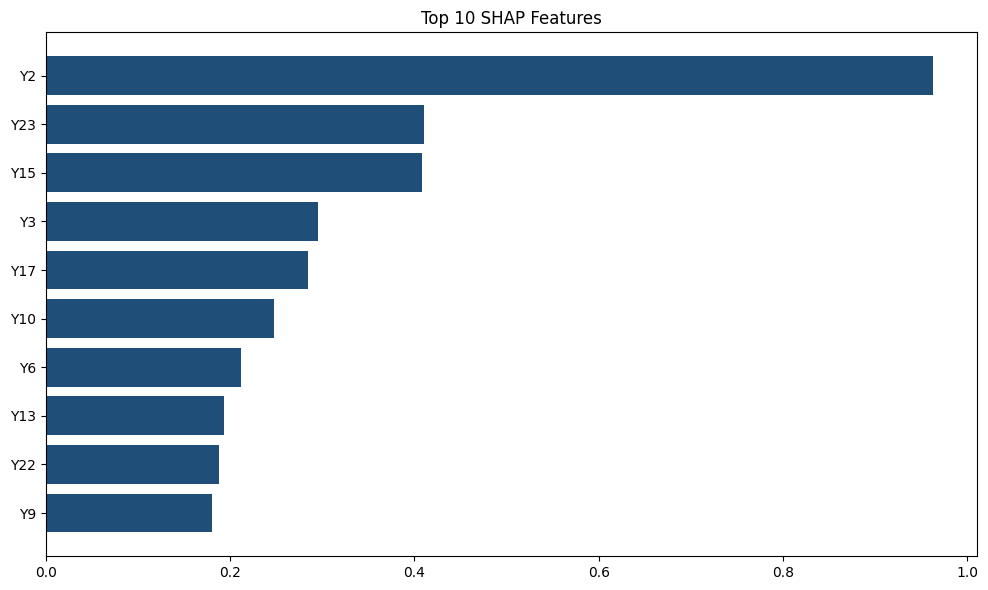

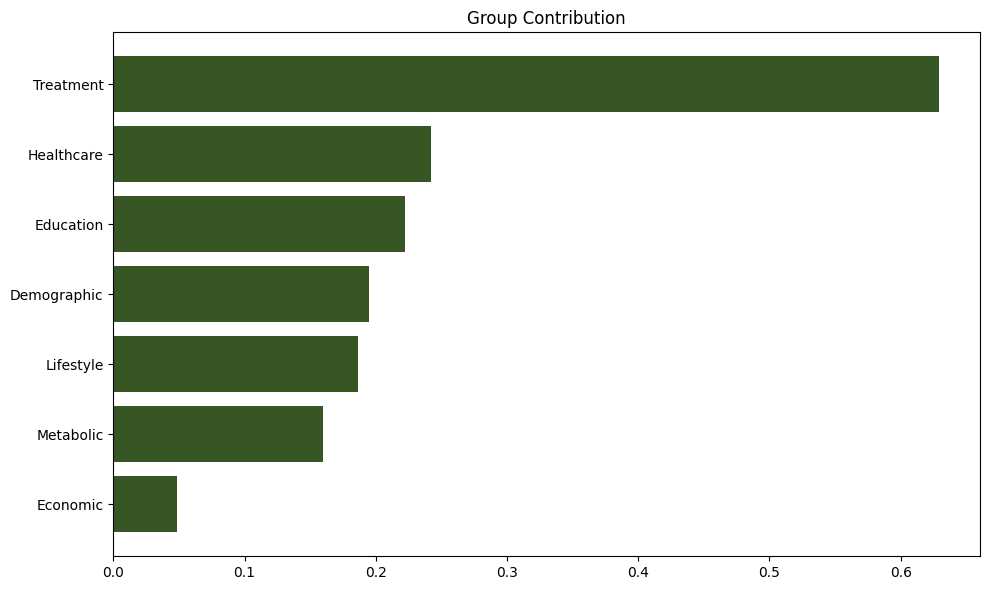

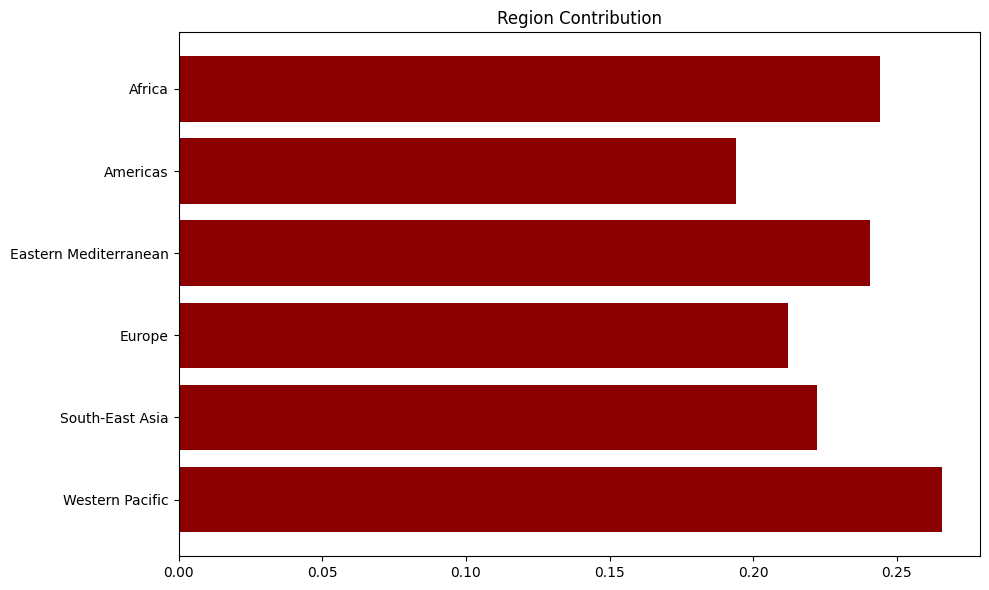

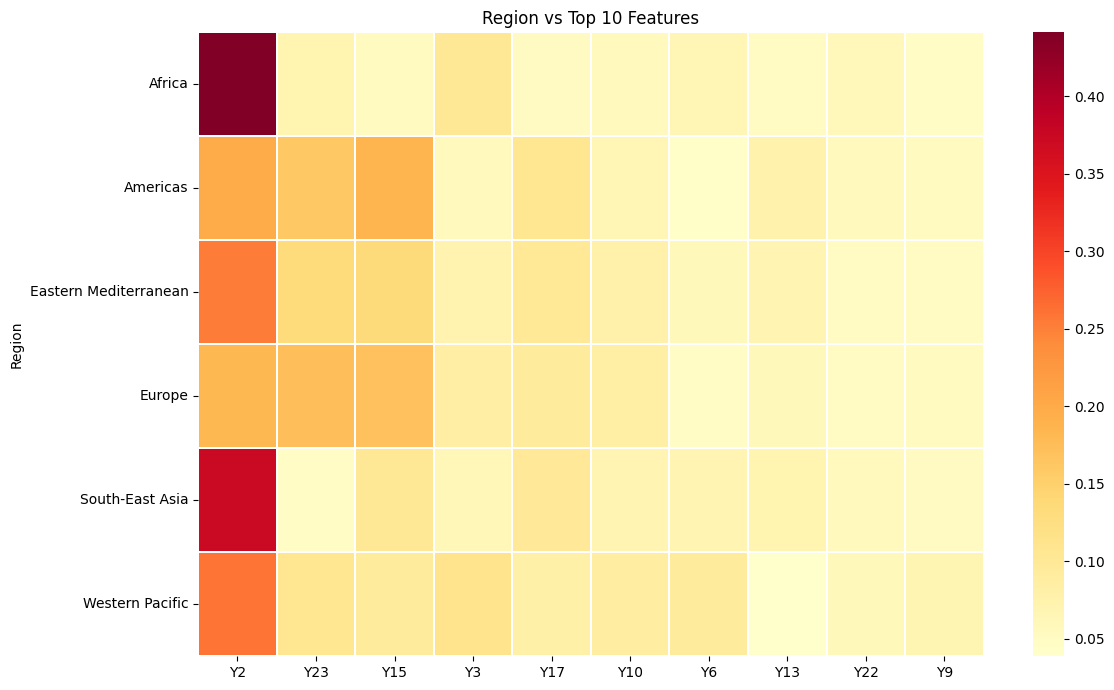

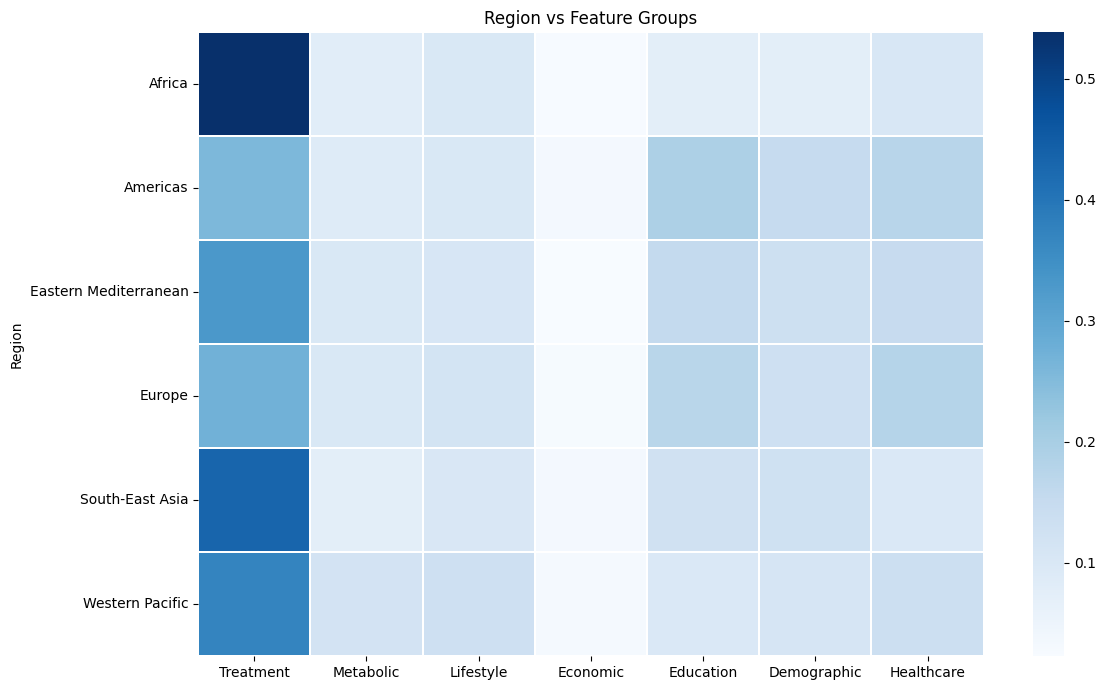


DONE ✔ ALL RESULTS SAVED
J:\Research\Research\database\results


In [7]:
# ═════════════════════════════════════════════════════════════════════
# RANDOM FOREST + SHAP FULL PIPELINE (FINAL CLEAN VERSION)
# ML + SHAP + GROUP + REGION + HEATMAPS
# Output: J:\Research\Research\database\results
# ═════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.ensemble import RandomForestRegressor

# -----------------------------
# 0. OUTPUT DIRECTORY
# -----------------------------
out_dir = r"J:\Research\Research\database\results"
os.makedirs(out_dir, exist_ok=True)

# -----------------------------
# 1. LOAD DATA
# -----------------------------
file_path = r"J:\Research\Research\database\Diabetes_Dataset.xlsx"
df = pd.read_excel(file_path, sheet_name="Data1")

# -----------------------------
# 2. VARIABLES
# -----------------------------
target = "X1"

features = [
    'Y2','Y3','Y5','Y6','Y7','Y8','Y9','Y10','Y11',
    'Y12','Y13','Y14','Y15','Y17','Y18','Y20','Y21','Y22','Y23'
]

country_col = "Country"
year_col = "Year"
region_col = "Region"

df = df[[region_col, country_col, year_col, target] + features].copy()
df = df.sort_values([country_col, year_col]).reset_index(drop=True)

# -----------------------------
# 3. MISSING VALUES
# -----------------------------
for c in features:
    df[c] = df.groupby(country_col)[c].ffill().bfill()

df[features] = df[features].fillna(df[features].median())
df = df.dropna(subset=[target])

# -----------------------------
# 4. TRAIN TEST SPLIT
# -----------------------------
train_df = df[df[year_col] <= 2017]
test_df  = df[df[year_col] >= 2018].reset_index(drop=True)

X_train = train_df[features].values
y_train = train_df[target].values

X_test  = test_df[features].values
y_test  = test_df[target].values

# -----------------------------
# 5. RANDOM FOREST MODEL
# -----------------------------
rf_model = RandomForestRegressor(
    n_estimators=600,
    max_depth=10,
    min_samples_leaf=3,
    min_samples_split=6,
    max_features=0.5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# -----------------------------
# 6. SHAP (COMPUTED ON TEST ONLY ONCE)
# -----------------------------
explainer = shap.TreeExplainer(rf_model)
shap_test = explainer.shap_values(X_test)

# align safely
test_df = test_df.iloc[:len(shap_test)].copy().reset_index(drop=True)

# -----------------------------
# 7. FEATURE SHAP DATAFRAME
# -----------------------------
shap_df = pd.DataFrame(np.abs(shap_test), columns=features)
shap_df["Region"] = test_df[region_col].values

# -----------------------------
# 8. TOP 10 FEATURES
# -----------------------------
mean_shap = shap_df[features].mean().values

imp_df = pd.DataFrame({
    "Feature": features,
    "SHAP_mean": mean_shap
}).sort_values("SHAP_mean", ascending=False).head(10)

top_features = imp_df["Feature"].tolist()

# -----------------------------
# 9. GROUP ANALYSIS
# -----------------------------
group_map = {
    
    "Treatment": ["Y1","Y2","Y3"],
    "Metabolic": ["Y5","Y6","Y7","Y8"],
    "Lifestyle": ["Y9","Y10","Y11"],
    "Economic": ["Y12","Y14"],
    "Education": ["Y13","Y15","Y18"],
    "Demographic": ["Y17","Y20"],
    "Healthcare": ["Y21","Y22","Y23"]
}

group_results = []
for g, vars_ in group_map.items():
    idx = [features.index(v) for v in vars_ if v in features]
    if len(idx) > 0:
        group_results.append([g, shap_df[features].iloc[:, idx].mean().mean()])

group_df = pd.DataFrame(group_results, columns=["Category","SHAP_mean"])
group_df = group_df.sort_values("SHAP_mean", ascending=False)

# -----------------------------
# 10. REGION LEVEL
# -----------------------------
region_df = shap_df.groupby("Region")[features].mean()
region_df["SHAP_mean"] = region_df.mean(axis=1)

region_summary = region_df[["SHAP_mean"]].reset_index()

# -----------------------------
# 11. SAVE EXCEL
# -----------------------------
excel_path = os.path.join(out_dir, "RF_SHAP_Results.xlsx")

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    imp_df.to_excel(writer, sheet_name="Top10", index=False)
    group_df.to_excel(writer, sheet_name="Groups", index=False)
    region_summary.to_excel(writer, sheet_name="Region", index=False)

# -----------------------------
# 12. FIGURE 1
# -----------------------------
plt.figure(figsize=(6,4))
plt.barh(imp_df["Feature"][::-1], imp_df["SHAP_mean"][::-1], color="#1F4E79")
plt.title("A", loc="left")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "Fig1.png"), dpi=300)
plt.show()

# -----------------------------
# 13. FIGURE 2
# -----------------------------
plt.figure(figsize=(6,4))
plt.barh(group_df["Category"][::-1], group_df["SHAP_mean"][::-1], color="#375623")
plt.title("B", loc="left", x=-0.2)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "Fig2.png"), dpi=300)
plt.show()



# ═════════════════════════════════════════════════════════════════════
# 15. HEATMAPS (PUBLICATION QUALITY)
# ═════════════════════════════════════════════════════════════════════

# -----------------------------
# REGION × TOP FEATURES
# -----------------------------
region_feat = shap_df.groupby("Region")[top_features].mean()
region_feat_norm = region_feat.div(region_feat.sum(axis=1), axis=0)

plt.figure(figsize=(6,4))
sns.heatmap(region_feat_norm, cmap="YlOrRd", linewidths=0.3)
plt.title("C", loc="left", x=-0.5)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "Fig4.png"), dpi=300)
plt.show()

# -----------------------------
# REGION × GROUP (REMOVE DIABETES)
# -----------------------------
filtered_group_map = {k:v for k,v in group_map.items() if k!="Diabetes"}

group_matrix = pd.DataFrame()
group_matrix["Region"] = shap_df["Region"]

for g, vars_ in filtered_group_map.items():
    idx = [features.index(v) for v in vars_ if v in features]
    group_matrix[g] = shap_df[features].iloc[:, idx].mean(axis=1)

group_region = group_matrix.groupby("Region").mean()
group_region_norm = group_region.div(group_region.sum(axis=1), axis=0)

plt.figure(figsize=(6,4))
sns.heatmap(group_region_norm, cmap="Blues", linewidths=0.3)
plt.title("D", loc="left", x=-0.5)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "Fig5.png"), dpi=300)
plt.show()

# -----------------------------
# FINAL MESSAGE
# -----------------------------
print("\nDONE ✔ ALL RESULTS SAVED")
print(out_dir)

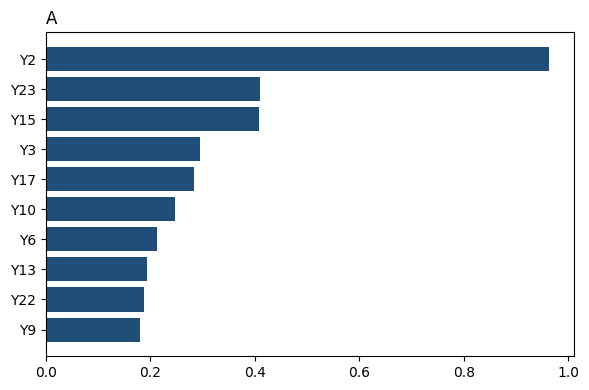

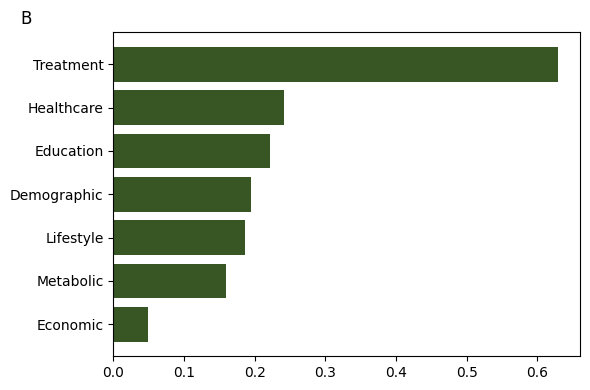

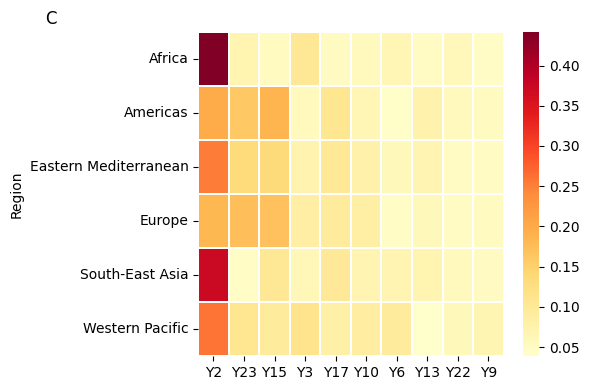

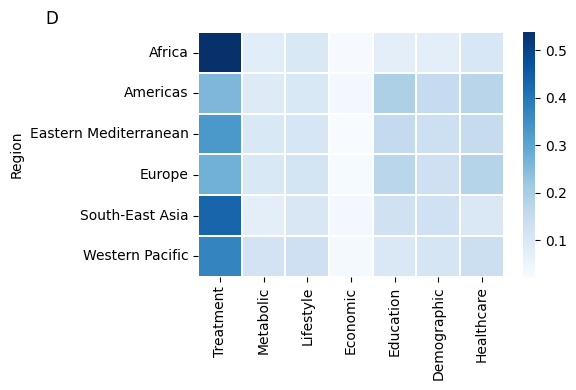


DONE ✔ ALL RESULTS SAVED
J:\Research\Research\database\results


In [22]:
# -----------------------------
# 12. FIGURE 1
# -----------------------------
plt.figure(figsize=(6,4))
plt.barh(imp_df["Feature"][::-1], imp_df["SHAP_mean"][::-1], color="#1F4E79")
plt.title("A", loc="left")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "Fig1.png"), dpi=300)
plt.show()

# -----------------------------
# 13. FIGURE 2
# -----------------------------
plt.figure(figsize=(6,4))
plt.barh(group_df["Category"][::-1], group_df["SHAP_mean"][::-1], color="#375623")
plt.title("B", loc="left", x=-0.2)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "Fig2.png"), dpi=300)
plt.show()



# ═════════════════════════════════════════════════════════════════════
# 15. HEATMAPS (PUBLICATION QUALITY)
# ═════════════════════════════════════════════════════════════════════

# -----------------------------
# REGION × TOP FEATURES
# -----------------------------
region_feat = shap_df.groupby("Region")[top_features].mean()
region_feat_norm = region_feat.div(region_feat.sum(axis=1), axis=0)

plt.figure(figsize=(6,4))
sns.heatmap(region_feat_norm, cmap="YlOrRd", linewidths=0.3)
plt.title("C", loc="left", x=-0.5)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "Fig4.png"), dpi=300)
plt.show()

# -----------------------------
# REGION × GROUP (REMOVE DIABETES)
# -----------------------------
filtered_group_map = {k:v for k,v in group_map.items() if k!="Diabetes"}

group_matrix = pd.DataFrame()
group_matrix["Region"] = shap_df["Region"]

for g, vars_ in filtered_group_map.items():
    idx = [features.index(v) for v in vars_ if v in features]
    group_matrix[g] = shap_df[features].iloc[:, idx].mean(axis=1)

group_region = group_matrix.groupby("Region").mean()
group_region_norm = group_region.div(group_region.sum(axis=1), axis=0)

plt.figure(figsize=(6,4))
sns.heatmap(group_region_norm, cmap="Blues", linewidths=0.3)
plt.title("D", loc="left", x=-0.5)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "Fig5.png"), dpi=300)
plt.show()

# -----------------------------
# FINAL MESSAGE
# -----------------------------
print("\nDONE ✔ ALL RESULTS SAVED")
print(out_dir)

In [5]:
"""
RF + SHAP PIPELINE — CLEAN VERSION
- No feature renaming (keep Y codes as-is)
- Separate figure files (no combining)
- Publication-quality font sizes
- 4-panel main figure: A(top10), B(group), C(region×top10), D(region×group)
- Excel saved in same output directory
- No caption text in figures
"""

import numpy as np
import pandas as pd
import shap
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess
import warnings, os
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
from openpyxl.drawing.image import Image as XLImage

# ══════════════════════════════════════════════════════════════════
# CONFIG
# ══════════════════════════════════════════════════════════════════
FILE_PATH   = r"J:\Research\Research\database\Diabetes_Dataset.xlsx"
OUT_DIR     = r"J:\Research\Research\database\results"
SUPP_DIR    = os.path.join(OUT_DIR, "Supporting_Figures")
os.makedirs(OUT_DIR,  exist_ok=True)
os.makedirs(SUPP_DIR, exist_ok=True)

TARGET      = "X1"
COUNTRY_COL = "Country"
YEAR_COL    = "Year"
REGION_COL  = "Region"

# Keep Y codes as-is — no renaming
FEATURES = [
    'Y2','Y3','Y5','Y6','Y7','Y8','Y9','Y10','Y11',
    'Y12','Y13','Y14','Y15','Y17','Y18','Y20','Y21','Y22','Y23'
]

# Use Y codes directly as labels
FEAT_LABELS = {f: f for f in FEATURES}

GROUP_MAP = {
    'Treatment'  : ['Y2','Y3'],
    'Metabolic'  : ['Y5','Y6','Y7','Y8'],
    'Lifestyle'  : ['Y9','Y10','Y11'],
    'Economic'   : ['Y12','Y14'],
    'Education'  : ['Y13','Y15','Y18'],
    'Demographic': ['Y17','Y20'],
    'Healthcare' : ['Y21','Y22','Y23'],
}

PAL = dict(
    blue    = '#1F4E79',
    ltblue  = '#2E75B6',
    sky     = '#4FC3F7',
    green   = '#375623',
    ltgreen = '#538135',
    teal    = '#00897B',
    red     = '#C0392B',
    orange  = '#E67E22',
    gold    = '#F4C430',
    purple  = '#6C3483',
    pink    = '#C0507A',
    gray    = '#5D6D7E',
    ltgray  = '#BDC3C7',
    bg      = '#F8FAFC',
    grid    = '#E5E7EB',
    zero    = '#374151',
)

GROUP_COLS = [
    PAL['blue'], PAL['ltblue'], PAL['teal'],
    PAL['green'], PAL['ltgreen'], PAL['orange'], PAL['red']
]

# Publication font settings
plt.rcParams.update({
    'font.family'      : 'Arial',
    'font.size'        : 13,
    'axes.titlesize'   : 15,
    'axes.labelsize'   : 14,
    'xtick.labelsize'  : 13,
    'ytick.labelsize'  : 13,
    'legend.fontsize'  : 12,
    'legend.title_fontsize': 13,
    'axes.linewidth'   : 1.0,
    'figure.dpi'       : 150,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

# ══════════════════════════════════════════════════════════════════
# 1. LOAD & SPLIT
# ══════════════════════════════════════════════════════════════════
df = pd.read_excel(FILE_PATH, sheet_name="Data1")
df = df[[REGION_COL, COUNTRY_COL, YEAR_COL, TARGET] + FEATURES].copy()
df = df.sort_values([COUNTRY_COL, YEAR_COL]).reset_index(drop=True)

for c in FEATURES:
    df[c] = df.groupby(COUNTRY_COL)[c].transform(
        lambda x: x.ffill().bfill()
    )
df[FEATURES] = df[FEATURES].fillna(df[FEATURES].median())
df = df.dropna(subset=[TARGET]).reset_index(drop=True)

train_df = df[df[YEAR_COL] <= 2017].reset_index(drop=True)
test_df  = df[df[YEAR_COL] >= 2018].reset_index(drop=True)
X_train  = train_df[FEATURES].values
y_train  = train_df[TARGET].values
X_test   = test_df[FEATURES].values
y_test   = test_df[TARGET].values

print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")

# ══════════════════════════════════════════════════════════════════
# 2. RF + SHAP
# ══════════════════════════════════════════════════════════════════
rf = RandomForestRegressor(
    n_estimators     = 600,
    max_depth        = 10,
    min_samples_leaf = 3,
    min_samples_split= 6,
    max_features     = 0.5,
    random_state     = 42,
    n_jobs           = -1,
)
rf.fit(X_train, y_train)

print("Computing SHAP values...")
explainer  = shap.TreeExplainer(rf)
shap_vals  = explainer.shap_values(X_test)
shap_abs   = np.abs(shap_vals)
mean_shap  = shap_abs.mean(axis=0)
total_shap = mean_shap.sum()
shap_pct   = mean_shap / total_shap * 100
feat_names = FEATURES   # keep as Y2, Y3, etc.

# Rank order high → low
rank_order  = np.argsort(mean_shap)[::-1]
rank_labels = [feat_names[i] for i in rank_order]

top10_idx    = rank_order[:10]
top10_labels = [feat_names[i] for i in top10_idx]
top3_idx     = rank_order[:3]
top3_labels  = [feat_names[i] for i in top3_idx]

# SHAP DataFrames
shap_df     = pd.DataFrame(shap_vals, columns=feat_names)
shap_abs_df = pd.DataFrame(shap_abs,  columns=feat_names)

for _d in [shap_df, shap_abs_df]:
    _d[REGION_COL]  = test_df[REGION_COL].values
    _d[COUNTRY_COL] = test_df[COUNTRY_COL].values
    _d[YEAR_COL]    = test_df[YEAR_COL].values

# Global importance table
importance_df = pd.DataFrame({
    'Rank'               : np.argsort(mean_shap)[::-1].argsort() + 1,
    'Feature'            : feat_names,
    'Mean_SHAP'          : shap_vals.mean(0).round(5),
    'Mean_abs_SHAP'      : mean_shap.round(5),
    'SHAP_Contribution_%': shap_pct.round(3),
    'Direction'          : ['Positive' if v > 0 else 'Negative'
                             for v in shap_vals.mean(0)],
}).sort_values('Rank').reset_index(drop=True)

# Group analysis
group_rows = []
for g, vars_ in GROUP_MAP.items():
    valid = [v for v in vars_ if v in FEATURES]
    idx   = [FEATURES.index(v) for v in valid]
    g_pct  = shap_pct[idx].sum()
    g_mean = shap_abs[:, idx].mean()
    lead   = feat_names[idx[int(np.argmax(mean_shap[idx]))]]
    group_rows.append(dict(
        Group                = g,
        Mean_abs_SHAP        = round(g_mean, 5),
        SHAP_Contribution_pct= round(g_pct, 3),
        N_Features           = len(valid),
        Lead_Feature         = lead,
        Features             = ', '.join(valid),
    ))
group_df = (pd.DataFrame(group_rows)
            .sort_values('SHAP_Contribution_pct', ascending=False)
            .reset_index(drop=True))
group_df.insert(0, 'Rank', range(1, len(group_df) + 1))

# Region × feature
reg_abs = shap_abs_df.groupby(REGION_COL)[feat_names].mean()
reg_pct = reg_abs.div(reg_abs.sum(axis=1), axis=0) * 100

# Region × group
grp_mat = pd.DataFrame({REGION_COL: shap_abs_df[REGION_COL]})
for g, vars_ in GROUP_MAP.items():
    valid = [v for v in vars_ if v in FEATURES]
    grp_mat[g] = shap_abs_df[valid].mean(axis=1)
reg_grp_abs = grp_mat.groupby(REGION_COL).mean()
reg_grp_pct = reg_grp_abs.div(reg_grp_abs.sum(axis=1), axis=0) * 100

# Country mean SHAP
ctry_df = test_df[[COUNTRY_COL, REGION_COL, TARGET]].copy()
for fn in feat_names:
    ctry_df[fn] = shap_df[fn].values
ctry_mean = ctry_df.groupby([COUNTRY_COL, REGION_COL]).mean().reset_index()
row_tot   = ctry_mean[feat_names].abs().sum(axis=1)
for fn in feat_names:
    ctry_mean[fn + '_pct'] = (ctry_mean[fn].abs() / row_tot * 100).round(3)

# Temporal SHAP
yr_df = test_df[[YEAR_COL]].copy()
for fn in feat_names:
    yr_df[fn] = shap_df[fn].values
yr_mean = yr_df.groupby(YEAR_COL).mean().reset_index()
yr_tot  = yr_mean[feat_names].abs().sum(axis=1)
for fn in feat_names:
    yr_mean[fn + '_pct'] = (yr_mean[fn].abs() / yr_tot * 100).round(3)

print("SHAP tables ready ✓")

# ══════════════════════════════════════════════════════════════════
# HELPER
# ══════════════════════════════════════════════════════════════════
def style_ax(ax, grid='x'):
    ax.set_facecolor(PAL['bg'])
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_axisbelow(True)
    if 'x' in grid:
        ax.xaxis.grid(True, color=PAL['grid'], lw=0.7)
    if 'y' in grid:
        ax.yaxis.grid(True, color=PAL['grid'], lw=0.7)

# ══════════════════════════════════════════════════════════════════
# MAIN FIGURE — 4 panels A B C D (2×2)
# ══════════════════════════════════════════════════════════════════
fig_main = plt.figure(figsize=(24, 20))
gs_m = gridspec.GridSpec(
    2, 2,
    figure  = fig_main,
    hspace  = 0.42,
    wspace  = 0.38,
    left    = 0.08,
    right   = 0.97,
    top     = 0.95,
    bottom  = 0.07,
)
axA = fig_main.add_subplot(gs_m[0, 0])
axB = fig_main.add_subplot(gs_m[0, 1])
axC = fig_main.add_subplot(gs_m[1, 0])
axD = fig_main.add_subplot(gs_m[1, 1])

# ── A: Top 10 feature SHAP contribution % ─────────────────────────
top10_pct    = shap_pct[top10_idx]
top10_dir    = shap_vals.mean(0)[top10_idx]
bar_cols_a   = [PAL['ltblue'] if d > 0 else PAL['red']
                for d in top10_dir]

# plot low→high (bottom to top)
sort_a = np.argsort(top10_pct)
bars_a = axA.barh(
    [top10_labels[i] for i in sort_a],
    top10_pct[sort_a],
    color     = [bar_cols_a[i] for i in sort_a],
    edgecolor = 'white',
    linewidth = 0.5,
    height    = 0.65,
)
for bar, val in zip(bars_a, top10_pct[sort_a]):
    axA.text(
        val + 0.10,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.2f}%',
        va       = 'center',
        fontsize = 12,
        color    = '#1a1a1a',
        fontweight = '600',
    )
axA.set_xlabel('SHAP Contribution (%)', fontsize=14, fontweight='600')
axA.set_title('A', fontsize=18, fontweight='bold', loc='left', pad=10)
style_ax(axA, 'x')
pos_p = mpatches.Patch(color=PAL['ltblue'], label='Positive effect')
neg_p = mpatches.Patch(color=PAL['red'],    label='Negative effect')
axA.legend(
    handles    = [pos_p, neg_p],
    fontsize   = 12,
    framealpha = 0.95,
    title      = 'Direction',
    title_fontsize = 13,
    loc        = 'lower right',
)

# ── B: Group SHAP contribution % ─────────────────────────────────
g_pcts = group_df['SHAP_Contribution_pct'].values
g_lbls = group_df['Group'].values

bars_b = axB.barh(
    g_lbls[::-1],
    g_pcts[::-1],
    color     = GROUP_COLS[:len(g_lbls)][::-1],
    edgecolor = 'white',
    linewidth = 0.5,
    height    = 0.6,
)
for bar, val in zip(bars_b, g_pcts[::-1]):
    axB.text(
        val + 0.10,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.2f}%',
        va         = 'center',
        fontsize   = 12,
        color      = '#1a1a1a',
        fontweight = '600',
    )
axB.set_xlabel('SHAP Contribution (%)', fontsize=14, fontweight='600')
axB.set_title('B', fontsize=18, fontweight='bold', loc='left', pad=10)
style_ax(axB, 'x')

# ── C: Region × Top 10 features heatmap (%) ──────────────────────
reg_pct_top10 = reg_pct[top10_labels]

sns.heatmap(
    reg_pct_top10,
    ax         = axC,
    cmap       = 'YlOrRd',
    linewidths = 0.4,
    linecolor  = 'white',
    annot      = reg_pct_top10.round(1),
    annot_kws  = {'fontsize': 11, 'fontweight': '600'},
    fmt        = '.1f',
    cbar_kws   = {'shrink': 0.85, 'label': 'SHAP Contribution (%)'},
)
axC.set_title('C', fontsize=18, fontweight='bold', loc='left', pad=10)
axC.set_xlabel('Feature', fontsize=14, fontweight='600')
axC.set_ylabel('Region', fontsize=14, fontweight='600')
axC.tick_params(axis='x', rotation=40, labelsize=12)
axC.tick_params(axis='y', rotation=0,  labelsize=12)
axC.collections[0].colorbar.ax.tick_params(labelsize=11)
axC.collections[0].colorbar.set_label('SHAP Contribution (%)', fontsize=12)

# ── D: Region × Group heatmap (%) ────────────────────────────────
sns.heatmap(
    reg_grp_pct,
    ax         = axD,
    cmap       = 'Blues',
    linewidths = 0.4,
    linecolor  = 'white',
    annot      = reg_grp_pct.round(1),
    annot_kws  = {'fontsize': 11, 'fontweight': '600'},
    fmt        = '.1f',
    cbar_kws   = {'shrink': 0.85, 'label': 'SHAP Contribution (%)'},
)
axD.set_title('D', fontsize=18, fontweight='bold', loc='left', pad=10)
axD.set_xlabel('Feature Group', fontsize=14, fontweight='600')
axD.set_ylabel('Region', fontsize=14, fontweight='600')
axD.tick_params(axis='x', rotation=30, labelsize=12)
axD.tick_params(axis='y', rotation=0,  labelsize=12)
axD.collections[0].colorbar.ax.tick_params(labelsize=11)
axD.collections[0].colorbar.set_label('SHAP Contribution (%)', fontsize=12)

p_main = os.path.join(OUT_DIR, 'Figure_Main_ABCD.png')
fig_main.savefig(p_main, dpi=300, bbox_inches='tight')
plt.close(fig_main)
print(f"Main figure saved → {p_main}")

# ══════════════════════════════════════════════════════════════════
# SUPPORTING FIGURES — each saved separately
# ══════════════════════════════════════════════════════════════════

# ── S1: Full beeswarm — ALL features ──────────────────────────────
fig_s1, ax_s1 = plt.subplots(figsize=(13, 12))
fig_s1.patch.set_facecolor('white')
np.random.seed(42)
for rank, fi in enumerate(rank_order[::-1]):
    sv   = shap_vals[:, fi]
    fv   = X_test[:, fi]
    norm = (fv - fv.min()) / (fv.max() - fv.min() + 1e-9)
    cols = plt.cm.RdBu_r(norm)
    jit  = np.random.uniform(-0.22, 0.22, len(sv))
    ax_s1.scatter(sv, rank + jit, c=cols, s=8,
                  alpha=0.55, linewidths=0, rasterized=True)
    ax_s1.scatter(sv.mean(), rank, c='black', s=55,
                  marker='D', edgecolors='white', linewidths=0.6, zorder=5)

ax_s1.axvline(0, color=PAL['zero'], linewidth=1.2)
ax_s1.set_yticks(range(len(FEATURES)))
ax_s1.set_yticklabels(rank_labels[::-1], fontsize=13)
ax_s1.set_xlabel('SHAP Value', fontsize=14, fontweight='600')
ax_s1.set_title('A', fontsize=18, fontweight='bold', loc='left', pad=10)
style_ax(ax_s1, 'x')

sm1 = ScalarMappable(cmap=plt.cm.RdBu_r, norm=Normalize(0, 1))
sm1.set_array([])
cb1 = fig_s1.colorbar(sm1, ax=ax_s1, shrink=0.4, pad=0.02)
cb1.set_ticks([0, 0.5, 1])
cb1.set_ticklabels(['Low', 'Mid', 'High'], fontsize=12)
cb1.set_label('Feature Value', fontsize=13)

fig_s1.tight_layout()
p_s1 = os.path.join(SUPP_DIR, 'S1_Beeswarm_AllFeatures.png')
fig_s1.savefig(p_s1, dpi=300, bbox_inches='tight')
plt.close(fig_s1)
print(f"S1 saved → {p_s1}")

# ── S2: SHAP dependence — all features (5 rows × 4 cols) ──────────
ncols_s2 = 4
nrows_s2 = int(np.ceil(len(FEATURES) / ncols_s2))
fig_s2, axes_s2 = plt.subplots(
    nrows_s2, ncols_s2,
    figsize=(ncols_s2 * 5.5, nrows_s2 * 4.5),
)
fig_s2.patch.set_facecolor('white')
axes_s2 = axes_s2.flatten()

for idx_p, fi in enumerate(rank_order):
    ax  = axes_s2[idx_p]
    sv  = shap_vals[:, fi]
    fv  = X_test[:, fi]
    fn  = (fv - fv.min()) / (fv.max() - fv.min() + 1e-9)
    ax.scatter(fn, sv, c=fn, cmap='RdBu_r', s=10,
               alpha=0.40, linewidths=0, rasterized=True,
               norm=Normalize(0, 1))
    si  = np.argsort(fn)
    smo = lowess(sv[si], fn[si], frac=0.40, it=2, return_sorted=True)
    ax.plot(smo[:, 0], smo[:, 1], color='black',
            linewidth=2.2, solid_capstyle='round', zorder=4)
    ax.axhline(0, color=PAL['zero'], linewidth=0.8,
               linestyle='--', alpha=0.6)
    ax.set_title(feat_names[fi], fontsize=13, fontweight='700', pad=5)
    ax.set_xlabel('Norm. Value', fontsize=12)
    ax.set_ylabel('SHAP', fontsize=12)
    ax.tick_params(labelsize=11)
    style_ax(ax, 'xy')
    ax.text(0.97, 0.95, f'{shap_pct[fi]:.2f}%',
            transform=ax.transAxes, fontsize=11,
            ha='right', va='top',
            color=PAL['blue'], fontweight='bold')

for j in range(len(FEATURES), len(axes_s2)):
    axes_s2[j].set_visible(False)

fig_s2.tight_layout(rect=[0, 0, 1, 0.98])
p_s2 = os.path.join(SUPP_DIR, 'S2_Dependence_AllFeatures.png')
fig_s2.savefig(p_s2, dpi=300, bbox_inches='tight')
plt.close(fig_s2)
print(f"S2 saved → {p_s2}")

# ── S3: Region × Feature — Mean |SHAP| heatmap ────────────────────
reg_abs_ranked = reg_abs[rank_labels]
fig_s3, ax_s3  = plt.subplots(figsize=(22, 7))
fig_s3.patch.set_facecolor('white')
sns.heatmap(
    reg_abs_ranked, ax=ax_s3, cmap='YlOrRd',
    linewidths=0.35, linecolor='white',
    annot=reg_abs_ranked.round(3),
    annot_kws={'fontsize': 11, 'fontweight': '600'},
    fmt='.3f',
    cbar_kws={'shrink': 0.8, 'label': 'Mean |SHAP|'},
)
ax_s3.set_title('A', fontsize=18, fontweight='bold', loc='left', pad=10)
ax_s3.set_xlabel('Feature (ranked by mean |SHAP|)', fontsize=14, fontweight='600')
ax_s3.set_ylabel('Region', fontsize=14, fontweight='600')
ax_s3.tick_params(axis='x', rotation=40, labelsize=12)
ax_s3.tick_params(axis='y', rotation=0,  labelsize=13)
ax_s3.collections[0].colorbar.ax.tick_params(labelsize=11)
ax_s3.collections[0].colorbar.set_label('Mean |SHAP|', fontsize=12)
fig_s3.tight_layout()
p_s3 = os.path.join(SUPP_DIR, 'S3_Region_Feature_MeanSHAP.png')
fig_s3.savefig(p_s3, dpi=300, bbox_inches='tight')
plt.close(fig_s3)
print(f"S3 saved → {p_s3}")

# ── S4: Region × Feature — SHAP % heatmap ─────────────────────────
reg_pct_ranked = reg_pct[rank_labels]
fig_s4, ax_s4  = plt.subplots(figsize=(22, 7))
fig_s4.patch.set_facecolor('white')
sns.heatmap(
    reg_pct_ranked, ax=ax_s4, cmap='Blues',
    linewidths=0.35, linecolor='white',
    annot=reg_pct_ranked.round(1),
    annot_kws={'fontsize': 11, 'fontweight': '600'},
    fmt='.1f',
    cbar_kws={'shrink': 0.8, 'label': 'SHAP Contribution (%)'},
)
ax_s4.set_title('B', fontsize=18, fontweight='bold', loc='left', pad=10)
ax_s4.set_xlabel('Feature (ranked by mean |SHAP|)', fontsize=14, fontweight='600')
ax_s4.set_ylabel('Region', fontsize=14, fontweight='600')
ax_s4.tick_params(axis='x', rotation=40, labelsize=12)
ax_s4.tick_params(axis='y', rotation=0,  labelsize=13)
ax_s4.collections[0].colorbar.ax.tick_params(labelsize=11)
ax_s4.collections[0].colorbar.set_label('SHAP Contribution (%)', fontsize=12)
fig_s4.tight_layout()
p_s4 = os.path.join(SUPP_DIR, 'S4_Region_Feature_SHAP_PCT.png')
fig_s4.savefig(p_s4, dpi=300, bbox_inches='tight')
plt.close(fig_s4)
print(f"S4 saved → {p_s4}")

# ── S5: Region × Group — Mean |SHAP| heatmap ──────────────────────
fig_s5, ax_s5 = plt.subplots(figsize=(14, 6))
fig_s5.patch.set_facecolor('white')
sns.heatmap(
    reg_grp_abs, ax=ax_s5, cmap='YlOrRd',
    linewidths=0.4, linecolor='white',
    annot=reg_grp_abs.round(4),
    annot_kws={'fontsize': 12, 'fontweight': '600'},
    fmt='.4f',
    cbar_kws={'shrink': 0.8, 'label': 'Mean |SHAP|'},
)
ax_s5.set_title('C', fontsize=18, fontweight='bold', loc='left', pad=10)
ax_s5.set_xlabel('Feature Group', fontsize=14, fontweight='600')
ax_s5.set_ylabel('Region', fontsize=14, fontweight='600')
ax_s5.tick_params(axis='x', rotation=30, labelsize=13)
ax_s5.tick_params(axis='y', rotation=0,  labelsize=13)
ax_s5.collections[0].colorbar.ax.tick_params(labelsize=11)
ax_s5.collections[0].colorbar.set_label('Mean |SHAP|', fontsize=12)
fig_s5.tight_layout()
p_s5 = os.path.join(SUPP_DIR, 'S5_Region_Group_MeanSHAP.png')
fig_s5.savefig(p_s5, dpi=300, bbox_inches='tight')
plt.close(fig_s5)
print(f"S5 saved → {p_s5}")

# ── S6: Region × Group — SHAP % heatmap ───────────────────────────
fig_s6, ax_s6 = plt.subplots(figsize=(14, 6))
fig_s6.patch.set_facecolor('white')
sns.heatmap(
    reg_grp_pct, ax=ax_s6, cmap='Blues',
    linewidths=0.4, linecolor='white',
    annot=reg_grp_pct.round(1),
    annot_kws={'fontsize': 12, 'fontweight': '600'},
    fmt='.1f',
    cbar_kws={'shrink': 0.8, 'label': 'SHAP Contribution (%)'},
)
ax_s6.set_title('D', fontsize=18, fontweight='bold', loc='left', pad=10)
ax_s6.set_xlabel('Feature Group', fontsize=14, fontweight='600')
ax_s6.set_ylabel('Region', fontsize=14, fontweight='600')
ax_s6.tick_params(axis='x', rotation=30, labelsize=13)
ax_s6.tick_params(axis='y', rotation=0,  labelsize=13)
ax_s6.collections[0].colorbar.ax.tick_params(labelsize=11)
ax_s6.collections[0].colorbar.set_label('SHAP Contribution (%)', fontsize=12)
fig_s6.tight_layout()
p_s6 = os.path.join(SUPP_DIR, 'S6_Region_Group_SHAP_PCT.png')
fig_s6.savefig(p_s6, dpi=300, bbox_inches='tight')
plt.close(fig_s6)
print(f"S6 saved → {p_s6}")

# ── S7: Temporal SHAP — all features separately ───────────────────
years_test = yr_mean[YEAR_COL].values
for fi in rank_order:
    fn_code = feat_names[fi]
    sv_yr   = yr_mean[fn_code].values
    pv_yr   = yr_mean[fn_code + '_pct'].values

    fig_yr, ax_yr = plt.subplots(figsize=(8, 5))
    fig_yr.patch.set_facecolor('white')
    ax_yr.fill_between(years_test, sv_yr, alpha=0.18, color=PAL['ltblue'])
    ax_yr.plot(years_test, sv_yr, marker='o', markersize=7,
               linewidth=2.2, color=PAL['blue'])
    ax_yr.axhline(0, color=PAL['zero'], linewidth=0.8,
                  linestyle='--', alpha=0.6)

    ax2_yr = ax_yr.twinx()
    ax2_yr.plot(years_test, pv_yr, marker='s', markersize=6,
                linewidth=2.0, color=PAL['orange'],
                linestyle='--', alpha=0.85)
    ax2_yr.set_ylabel('SHAP Contribution (%)',
                      fontsize=13, color=PAL['orange'])
    ax2_yr.tick_params(axis='y', labelsize=12, colors=PAL['orange'])
    ax2_yr.spines[['top', 'right']].set_visible(False)

    ax_yr.set_xlabel('Year', fontsize=14, fontweight='600')
    ax_yr.set_ylabel('Mean SHAP', fontsize=14, fontweight='600')
    ax_yr.set_title(fn_code, fontsize=16, fontweight='bold', loc='left')
    ax_yr.tick_params(labelsize=13)
    style_ax(ax_yr, 'y')

    fig_yr.tight_layout()
    p_yr = os.path.join(SUPP_DIR, f'S7_Temporal_{fn_code}.png')
    fig_yr.savefig(p_yr, dpi=300, bbox_inches='tight')
    plt.close(fig_yr)

print("S7 temporal figures saved")

# ── S8: Country SHAP heatmap — top 10 features ────────────────────
ctry_heat = ctry_mean.set_index(COUNTRY_COL)[top10_labels].sort_values(
    top10_labels[0], ascending=False
)
fig_s8, ax_s8 = plt.subplots(
    figsize=(18, max(10, len(ctry_heat) * 0.22))
)
fig_s8.patch.set_facecolor('white')
sns.heatmap(
    ctry_heat, ax=ax_s8, cmap='RdBu_r', center=0,
    linewidths=0.15, linecolor='#E0E0E0',
    cbar_kws={'shrink': 0.5, 'label': 'Mean SHAP Value'},
    xticklabels=True, yticklabels=True,
)
ax_s8.set_title('A', fontsize=18, fontweight='bold', loc='left', pad=10)
ax_s8.set_xlabel('Feature (Top 10)', fontsize=14, fontweight='600')
ax_s8.set_ylabel('Country', fontsize=14, fontweight='600')
ax_s8.tick_params(axis='x', rotation=35, labelsize=12)
ax_s8.tick_params(axis='y', labelsize=7)
ax_s8.collections[0].colorbar.ax.tick_params(labelsize=11)
ax_s8.collections[0].colorbar.set_label('Mean SHAP Value', fontsize=12)
fig_s8.tight_layout()
p_s8 = os.path.join(SUPP_DIR, 'S8_Country_SHAP_Top10.png')
fig_s8.savefig(p_s8, dpi=300, bbox_inches='tight')
plt.close(fig_s8)
print(f"S8 saved → {p_s8}")

# ── S9: Per-region beeswarm — each region separately ──────────────
regions = sorted(test_df[REGION_COL].unique())
for reg in regions:
    mask   = test_df[REGION_COL].values == reg
    sv_r   = shap_vals[mask]
    fv_r   = X_test[mask]
    mean_r = np.abs(sv_r).mean(0)
    ord_r  = np.argsort(mean_r)
    show_n = min(10, len(FEATURES))
    top_r  = ord_r[-show_n:]

    fig_r, ax_r = plt.subplots(figsize=(10, 7))
    fig_r.patch.set_facecolor('white')
    np.random.seed(42)
    for rank, fi in enumerate(top_r[::-1]):
        sv   = sv_r[:, fi]
        fv   = fv_r[:, fi]
        norm = (fv - fv.min()) / (fv.max() - fv.min() + 1e-9)
        cols = plt.cm.RdBu_r(norm)
        jit  = np.random.uniform(-0.22, 0.22, len(sv))
        ax_r.scatter(sv, rank + jit, c=cols, s=10,
                     alpha=0.55, linewidths=0, rasterized=True)
        ax_r.scatter(sv.mean(), rank, c='black', s=55,
                     marker='D', edgecolors='white',
                     linewidths=0.6, zorder=5)
    ax_r.axvline(0, color=PAL['zero'], linewidth=1.2)
    ax_r.set_yticks(range(show_n))
    ax_r.set_yticklabels(
        [feat_names[i] for i in top_r[::-1]], fontsize=13
    )
    ax_r.set_xlabel('SHAP Value', fontsize=14, fontweight='600')
    ax_r.set_title(reg, fontsize=16, fontweight='bold', loc='left', pad=8)
    ax_r.text(0.98, 0.02, f'n={mask.sum():,}',
              transform=ax_r.transAxes, fontsize=12,
              ha='right', color=PAL['gray'])
    style_ax(ax_r, 'x')

    sm_r = ScalarMappable(cmap=plt.cm.RdBu_r, norm=Normalize(0, 1))
    sm_r.set_array([])
    cb_r = fig_r.colorbar(sm_r, ax=ax_r, shrink=0.45, pad=0.02)
    cb_r.set_ticks([0, 0.5, 1])
    cb_r.set_ticklabels(['Low', 'Mid', 'High'], fontsize=12)
    cb_r.set_label('Feature Value', fontsize=13)

    fig_r.tight_layout()
    reg_safe = reg.replace(' ', '_').replace('/', '_')
    p_r = os.path.join(SUPP_DIR, f'S9_Beeswarm_{reg_safe}.png')
    fig_r.savefig(p_r, dpi=300, bbox_inches='tight')
    plt.close(fig_r)

print("S9 region beeswarms saved")

# ── S10: Stacked bar — region × group % ───────────────────────────
fig_s10, ax_s10 = plt.subplots(figsize=(14, 7))
fig_s10.patch.set_facecolor('white')
reg_grp_pct.plot(
    kind      = 'barh',
    stacked   = True,
    ax        = ax_s10,
    color     = GROUP_COLS[:len(GROUP_MAP)],
    edgecolor = 'white',
    linewidth = 0.5,
)
ax_s10.set_xlabel('SHAP Contribution (%)', fontsize=14, fontweight='600')
ax_s10.set_ylabel('Region', fontsize=14, fontweight='600')
ax_s10.set_title('A', fontsize=18, fontweight='bold', loc='left', pad=10)
ax_s10.legend(
    title          = 'Feature Group',
    fontsize       = 12,
    title_fontsize = 13,
    bbox_to_anchor = (1.01, 1),
    loc            = 'upper left',
    framealpha     = 0.95,
)
ax_s10.tick_params(axis='y', labelsize=13)
ax_s10.tick_params(axis='x', labelsize=12)
ax_s10.set_xlim(0, 105)
style_ax(ax_s10, 'x')
fig_s10.tight_layout()
p_s10 = os.path.join(SUPP_DIR, 'S10_StackedBar_Region_Group.png')
fig_s10.savefig(p_s10, dpi=300, bbox_inches='tight')
plt.close(fig_s10)
print(f"S10 saved → {p_s10}")

# ── S11: Stacked bar — region × top 10 features % ─────────────────
reg_pct_top10 = reg_pct[top10_labels]
top10_cols    = plt.cm.tab10(np.linspace(0, 1, 10))
fig_s11, ax_s11 = plt.subplots(figsize=(14, 7))
fig_s11.patch.set_facecolor('white')
reg_pct_top10.plot(
    kind      = 'barh',
    stacked   = True,
    ax        = ax_s11,
    color     = top10_cols,
    edgecolor = 'white',
    linewidth = 0.4,
)
ax_s11.set_xlabel('SHAP Contribution (%)', fontsize=14, fontweight='600')
ax_s11.set_ylabel('Region', fontsize=14, fontweight='600')
ax_s11.set_title('B', fontsize=18, fontweight='bold', loc='left', pad=10)
ax_s11.legend(
    title          = 'Feature (Top 10)',
    fontsize       = 11,
    title_fontsize = 13,
    bbox_to_anchor = (1.01, 1),
    loc            = 'upper left',
    framealpha     = 0.95,
)
ax_s11.tick_params(axis='y', labelsize=13)
ax_s11.tick_params(axis='x', labelsize=12)
ax_s11.set_xlim(0, 105)
style_ax(ax_s11, 'x')
fig_s11.tight_layout()
p_s11 = os.path.join(SUPP_DIR, 'S11_StackedBar_Region_Top10.png')
fig_s11.savefig(p_s11, dpi=300, bbox_inches='tight')
plt.close(fig_s11)
print(f"S11 saved → {p_s11}")

# ══════════════════════════════════════════════════════════════════
# EXCEL — saved in OUT_DIR (same as main figure)
# ══════════════════════════════════════════════════════════════════
print("\nBuilding Excel workbook...")

wb  = openpyxl.Workbook()
wb.remove(wb.active)

def SF(bold=False, sz=11, col='000000', italic=False):
    return Font(name='Arial', bold=bold, size=sz,
                color=col, italic=italic)
def FF(c):
    return PatternFill('solid', start_color=c)
CA  = Alignment(horizontal='center', vertical='center', wrap_text=True)
CLA = Alignment(horizontal='left',   vertical='center', wrap_text=False)
thin = Side(style='thin', color='BFBFBF')
B    = Border(left=thin, right=thin, top=thin, bottom=thin)

def ap(cell, font=None, fill=None, align=None, border=None):
    if font:   cell.font      = font
    if fill:   cell.fill      = fill
    if align:  cell.alignment = align
    if border: cell.border    = border

def title_row(ws, text, ncols, fill='1F4E79', sz=13):
    ws.merge_cells(f'A1:{get_column_letter(ncols)}1')
    ws['A1'] = text
    ap(ws['A1'], SF(True, sz, 'FFFFFF'), FF(fill), CA)
    ws.row_dimensions[1].height = 30

def col_header(ws, row, headers, fill='2E75B6'):
    for j, h in enumerate(headers, 1):
        ap(ws.cell(row, j, h),
           SF(True, 11, 'FFFFFF'), FF(fill), CA, B)
    ws.row_dimensions[row].height = 22

def data_row(ws, row, values, bold=False, fill_hex=None):
    alt = 'F2F7FC' if row % 2 == 0 else 'FFFFFF'
    fh  = fill_hex or alt
    for j, v in enumerate(values, 1):
        al = CLA if j == 1 else CA
        ap(ws.cell(row, j, v),
           SF(bold, 11, '1F3864' if bold else '000000'),
           FF(fh), al, B)
    ws.row_dimensions[row].height = 18

def set_col_widths(ws, widths):
    for i, w in enumerate(widths, 1):
        ws.column_dimensions[get_column_letter(i)].width = w

# ── Sheet 1: README ───────────────────────────────────────────────
ws0 = wb.create_sheet('README')
ws0.sheet_view.showGridLines = False
title_row(ws0, 'RF + SHAP Analysis — Workbook Contents', 3)

sheet_guide = [
    ('1_GlobalRanking',     'All features ranked by SHAP Contribution (%) + mean |SHAP| + direction'),
    ('2_GroupContribution', 'Feature groups ranked by SHAP Contribution (%)'),
    ('3_Region_Feature_abs','Region × Feature — Mean |SHAP|'),
    ('4_Region_Feature_pct','Region × Feature — SHAP Contribution (%) row-normalised'),
    ('5_Region_Group_abs',  'Region × Group — Mean |SHAP|'),
    ('6_Region_Group_pct',  'Region × Group — SHAP Contribution (%) row-normalised'),
    ('7_Country_SHAP',      'Country-level mean SHAP and SHAP Contribution % per feature'),
    ('8_Temporal_SHAP',     'Year-level mean SHAP and SHAP Contribution % per feature (2018-2022)'),
    ('9_RawSHAP_Test',      'Raw signed SHAP values for every test observation'),
    ('10_Figures',          'Embedded main and supporting figures'),
]
ws0.merge_cells('A2:C2')
ws0['A2'] = 'Train: 1990-2017  |  Test: 2018-2022  |  SHAP computed on test set'
ap(ws0['A2'], SF(False, 10, 'FFFFFF', True), FF('2E75B6'), CA)
ws0.row_dimensions[2].height = 18

for i, (sh, desc) in enumerate(sheet_guide, 4):
    ws0.cell(i, 1, sh)
    ws0.cell(i, 2, desc)
    fh = 'DDEBF7' if i % 2 == 0 else 'EBF5FB'
    ap(ws0.cell(i, 1), SF(True, 10, '1F4E79'), FF(fh), CLA, B)
    ws0.merge_cells(f'B{i}:C{i}')
    ap(ws0.cell(i, 2), SF(False, 10), FF(fh), CLA, B)
    ws0.row_dimensions[i].height = 18

set_col_widths(ws0, [30, 75, 5])

# ── Sheet 2: Global Ranking ───────────────────────────────────────
ws1 = wb.create_sheet('1_GlobalRanking')
ws1.sheet_view.showGridLines = False
title_row(ws1, 'SHAP Global Feature Importance (Test Set 2018-2022)', 7)
col_header(ws1, 2, ['Rank', 'Feature', 'Mean SHAP (signed)',
                     'Mean |SHAP|', 'SHAP Contribution (%)',
                     'Direction', 'Cumulative %'])
cum = 0
for i, row in importance_df.iterrows():
    cum += row['SHAP_Contribution_%']
    top3f = row['Rank'] <= 3
    data_row(ws1, i + 3, [
        row['Rank'], row['Feature'],
        round(row['Mean_SHAP'], 5),
        round(row['Mean_abs_SHAP'], 5),
        f"{row['SHAP_Contribution_%']:.3f}%",
        row['Direction'],
        f"{cum:.2f}%",
    ], bold=top3f, fill_hex='FFF9C4' if top3f else None)
set_col_widths(ws1, [6, 14, 18, 14, 22, 12, 14])
ws1.freeze_panes = 'A3'

# ── Sheet 3: Group Contribution ───────────────────────────────────
ws2 = wb.create_sheet('2_GroupContribution')
ws2.sheet_view.showGridLines = False
title_row(ws2, 'SHAP Feature Group Contribution (Test Set 2018-2022)', 6,
          fill='375623')
col_header(ws2, 2,
           ['Rank', 'Group', 'Mean |SHAP|',
            'SHAP Contribution (%)', 'Lead Feature', 'Features'],
           fill='538135')
g_fills = ['FFF9C4','E2EFDA','DDEBF7','FCE4D6','F0E6FF','EBF5FB','FDE9D9']
for i, row in group_df.iterrows():
    data_row(ws2, i + 3, [
        row['Rank'], row['Group'],
        round(row['Mean_abs_SHAP'], 5),
        f"{row['SHAP_Contribution_pct']:.3f}%",
        row['Lead_Feature'], row['Features'],
    ], bold=(i == 0), fill_hex=g_fills[i % len(g_fills)])
set_col_widths(ws2, [6, 16, 14, 22, 16, 50])

# ── Sheet 4: Region × Feature abs ────────────────────────────────
ws3 = wb.create_sheet('3_Region_Feature_abs')
ws3.sheet_view.showGridLines = False
rank_lbl = rank_labels
ncols3   = len(rank_lbl) + 1
title_row(ws3, 'Region x Feature — Mean |SHAP| (Test Set 2018-2022)', ncols3)
col_header(ws3, 2, ['Region'] + rank_lbl)
ws3.row_dimensions[2].height = 55
mat3 = reg_abs[rank_lbl].reset_index()
for i, row in mat3.iterrows():
    r = i + 3
    alt = 'F2F7FC' if r % 2 == 0 else 'FFFFFF'
    ap(ws3.cell(r, 1, row[REGION_COL]),
       SF(True, 11), FF('DDEBF7'), CLA, B)
    for j, fn in enumerate(rank_lbl, 2):
        ap(ws3.cell(r, j, round(row[fn], 4)),
           SF(False, 11), FF(alt), CA, B)
    ws3.row_dimensions[r].height = 18
ws3.column_dimensions['A'].width = 22
for j in range(2, ncols3 + 1):
    ws3.column_dimensions[get_column_letter(j)].width = 14
ws3.freeze_panes = 'B3'

# ── Sheet 5: Region × Feature pct ────────────────────────────────
ws4 = wb.create_sheet('4_Region_Feature_pct')
ws4.sheet_view.showGridLines = False
ncols4 = len(rank_lbl) + 1
title_row(ws4, 'Region x Feature — SHAP Contribution % (Test Set 2018-2022)',
          ncols4, fill='375623')
col_header(ws4, 2, ['Region'] + rank_lbl, fill='538135')
ws4.row_dimensions[2].height = 55
mat4 = reg_pct[rank_lbl].reset_index()
for i, row in mat4.iterrows():
    r = i + 3
    alt = 'E2EFDA' if r % 2 == 0 else 'FFFFFF'
    ap(ws4.cell(r, 1, row[REGION_COL]),
       SF(True, 11), FF('DDEBF7'), CLA, B)
    for j, fn in enumerate(rank_lbl, 2):
        ap(ws4.cell(r, j, round(row[fn], 2)),
           SF(False, 11), FF(alt), CA, B)
    ws4.row_dimensions[r].height = 18
ws4.column_dimensions['A'].width = 22
for j in range(2, ncols4 + 1):
    ws4.column_dimensions[get_column_letter(j)].width = 14
ws4.freeze_panes = 'B3'

# ── Sheet 6: Region × Group abs ──────────────────────────────────
ws5 = wb.create_sheet('5_Region_Group_abs')
ws5.sheet_view.showGridLines = False
grp_cols_list = list(reg_grp_abs.columns)
ncols5 = len(grp_cols_list) + 1
title_row(ws5, 'Region x Group — Mean |SHAP| (Test Set 2018-2022)', ncols5)
col_header(ws5, 2, ['Region'] + grp_cols_list)
mat5 = reg_grp_abs.reset_index()
for i, row in mat5.iterrows():
    r = i + 3
    alt = 'F2F7FC' if r % 2 == 0 else 'FFFFFF'
    ap(ws5.cell(r, 1, row[REGION_COL]),
       SF(True, 11), FF('DDEBF7'), CLA, B)
    for j, g in enumerate(grp_cols_list, 2):
        ap(ws5.cell(r, j, round(row[g], 4)),
           SF(False, 11), FF(alt), CA, B)
    ws5.row_dimensions[r].height = 18
ws5.column_dimensions['A'].width = 22
for j in range(2, ncols5 + 1):
    ws5.column_dimensions[get_column_letter(j)].width = 18

# ── Sheet 7: Region × Group pct ──────────────────────────────────
ws6 = wb.create_sheet('6_Region_Group_pct')
ws6.sheet_view.showGridLines = False
ncols6 = len(grp_cols_list) + 1
title_row(ws6, 'Region x Group — SHAP Contribution % (Test Set 2018-2022)',
          ncols6, fill='375623')
col_header(ws6, 2, ['Region'] + grp_cols_list, fill='538135')
mat6 = reg_grp_pct.reset_index()
for i, row in mat6.iterrows():
    r = i + 3
    alt = 'E2EFDA' if r % 2 == 0 else 'FFFFFF'
    ap(ws6.cell(r, 1, row[REGION_COL]),
       SF(True, 11), FF('DDEBF7'), CLA, B)
    for j, g in enumerate(grp_cols_list, 2):
        ap(ws6.cell(r, j, round(row[g], 2)),
           SF(False, 11), FF(alt), CA, B)
    ws6.row_dimensions[r].height = 18
ws6.column_dimensions['A'].width = 22
for j in range(2, ncols6 + 1):
    ws6.column_dimensions[get_column_letter(j)].width = 18

# ── Sheet 8: Country SHAP ─────────────────────────────────────────
ws7 = wb.create_sheet('7_Country_SHAP')
ws7.sheet_view.showGridLines = False
shap_c  = feat_names
pct_c   = [fn + '_pct' for fn in feat_names]
ncols7  = 2 + len(shap_c) + len(pct_c)
title_row(ws7, 'Country-Level Mean SHAP (Test Set 2018-2022)', ncols7)
col_header(ws7, 2,
           [COUNTRY_COL, REGION_COL] +
           [f'{fn} SHAP' for fn in shap_c] +
           [f'{fn} %'    for fn in shap_c])
ws7.row_dimensions[2].height = 55

ctry_sort = ctry_mean.sort_values(
    [REGION_COL, COUNTRY_COL]
).reset_index(drop=True)

for i, row in ctry_sort.iterrows():
    r = i + 3
    alt = 'F2F7FC' if r % 2 == 0 else 'FFFFFF'
    ap(ws7.cell(r, 1, row[COUNTRY_COL]),
       SF(False, 11), FF(alt), CLA, B)
    ap(ws7.cell(r, 2, row[REGION_COL]),
       SF(False, 11), FF(alt), CLA, B)
    for j, fn in enumerate(shap_c, 3):
        ap(ws7.cell(r, j, round(row[fn], 5)),
           SF(False, 11), FF(alt), CA, B)
    for j, fn in enumerate(pct_c, 3 + len(shap_c)):
        ap(ws7.cell(r, j, round(row[fn], 3)),
           SF(False, 11), FF(alt), CA, B)
    ws7.row_dimensions[r].height = 14

ws7.column_dimensions['A'].width = 25
ws7.column_dimensions['B'].width = 20
for j in range(3, ncols7 + 1):
    ws7.column_dimensions[get_column_letter(j)].width = 14
ws7.freeze_panes = 'C3'

# ── Sheet 9: Temporal SHAP ────────────────────────────────────────
ws8 = wb.create_sheet('8_Temporal_SHAP')
ws8.sheet_view.showGridLines = False
pct_yr  = [fn + '_pct' for fn in feat_names]
ncols8  = 1 + len(feat_names) + len(pct_yr)
title_row(ws8, 'Year-Level Mean SHAP (Test Period 2018-2022)', ncols8)
col_header(ws8, 2,
           [YEAR_COL] +
           [f'{fn} SHAP' for fn in feat_names] +
           [f'{fn} %'    for fn in feat_names])
ws8.row_dimensions[2].height = 55

for i, row in yr_mean.iterrows():
    r = i + 3
    alt = 'EBF5FB' if r % 2 == 0 else 'FFFFFF'
    ap(ws8.cell(r, 1, int(row[YEAR_COL])),
       SF(True, 11), FF(alt), CA, B)
    for j, fn in enumerate(feat_names, 2):
        ap(ws8.cell(r, j, round(row[fn], 5)),
           SF(False, 11), FF(alt), CA, B)
    for j, fn in enumerate(pct_yr, 2 + len(feat_names)):
        ap(ws8.cell(r, j, round(row[fn], 3)),
           SF(False, 11), FF(alt), CA, B)
    ws8.row_dimensions[r].height = 18

ws8.column_dimensions['A'].width = 10
for j in range(2, ncols8 + 1):
    ws8.column_dimensions[get_column_letter(j)].width = 14
ws8.freeze_panes = 'B3'

# ── Sheet 10: Raw SHAP ────────────────────────────────────────────
ws9 = wb.create_sheet('9_RawSHAP_Test')
ws9.sheet_view.showGridLines = False
ncols9 = 3 + len(feat_names)
title_row(ws9, 'Raw Signed SHAP Values — Test Observations (2018-2022)', ncols9)
col_header(ws9, 2,
           [COUNTRY_COL, REGION_COL, YEAR_COL] + feat_names)
ws9.row_dimensions[2].height = 55

raw_df = test_df[[COUNTRY_COL, REGION_COL, YEAR_COL]].copy()
for i_f, fn in enumerate(feat_names):
    raw_df[fn] = shap_vals[:, i_f]
raw_df = raw_df.sort_values(
    [REGION_COL, COUNTRY_COL, YEAR_COL]
).reset_index(drop=True)

for i, row in raw_df.iterrows():
    r   = i + 3
    alt = 'F2F7FC' if r % 2 == 0 else 'FFFFFF'
    ap(ws9.cell(r, 1, row[COUNTRY_COL]),
       SF(False, 10), FF(alt), CLA, B)
    ap(ws9.cell(r, 2, row[REGION_COL]),
       SF(False, 10), FF(alt), CLA, B)
    ap(ws9.cell(r, 3, int(row[YEAR_COL])),
       SF(False, 10), FF(alt), CA, B)
    for j, fn in enumerate(feat_names, 4):
        ap(ws9.cell(r, j, round(row[fn], 5)),
           SF(False, 10), FF(alt), CA, B)
    ws9.row_dimensions[r].height = 13

ws9.column_dimensions['A'].width = 25
ws9.column_dimensions['B'].width = 20
ws9.column_dimensions['C'].width = 8
for j in range(4, ncols9 + 1):
    ws9.column_dimensions[get_column_letter(j)].width = 14
ws9.freeze_panes = 'D3'

# ── Sheet 11: Figures ─────────────────────────────────────────────
ws_fig = wb.create_sheet('10_Figures')
ws_fig.sheet_view.showGridLines = False
title_row(ws_fig, 'Publication Figures — Main and Supporting', 2)

fig_embed = [
    (p_main, 'Main Figure — A(Top10 SHAP%) B(Group SHAP%) C(Region×Top10) D(Region×Group)', 3),
    (p_s1,   'S1: Beeswarm — All Features', 55),
    (p_s2,   'S2: Dependence Plots — All Features', 115),
    (p_s3,   'S3: Region × Feature Mean |SHAP|', 195),
    (p_s4,   'S4: Region × Feature SHAP %', 240),
    (p_s5,   'S5: Region × Group Mean |SHAP|', 285),
    (p_s6,   'S6: Region × Group SHAP %', 325),
    (p_s8,   'S8: Country SHAP Heatmap Top 10', 365),
    (p_s10,  'S10: Stacked Bar Region × Group', 440),
    (p_s11,  'S11: Stacked Bar Region × Top10', 490),
]
for fp, lbl, anchor_row in fig_embed:
    ap(ws_fig.cell(anchor_row - 1, 1, lbl),
       SF(True, 12, '1F4E79'), FF('DDEBF7'), CLA)
    if os.path.exists(fp):
        img = XLImage(fp)
        img.width  = 1000
        img.height = int(1000 * 0.62)
        ws_fig.add_image(img, f'A{anchor_row}')
ws_fig.column_dimensions['A'].width = 130

# ── Save Excel ────────────────────────────────────────────────────
excel_out = os.path.join(OUT_DIR, 'RF_SHAP_Results.xlsx')
wb.save(excel_out)

print(f"\n{'='*60}")
print("DONE ✔")
print(f"  Main figure    : {p_main}")
print(f"  Supporting figs: {SUPP_DIR}")
print(f"  Excel workbook : {excel_out}")
print(f"{'='*60}")

KeyError: "None of [Index([0, 18, 12, 1, 13, 7, 3, 17, 6, 10], dtype='int64')] are in the [columns]"

"""
RF + SHAP PIPELINE — CLEAN VERSION
- No feature renaming (keep Y codes as-is)
- Separate figure files (no combining)
- Publication-quality font sizes
- 4-panel main figure: A(top10), B(group), C(region×top10), D(region×group)
- Excel saved in same output directory
- No caption text in figures
"""

import numpy as np
import pandas as pd
import shap
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess
import warnings, os
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
from openpyxl.drawing.image import Image as XLImage

# ══════════════════════════════════════════════════════════════════
# CONFIG
# ══════════════════════════════════════════════════════════════════
FILE_PATH   = r"J:\Research\Research\database\Diabetes_Dataset.xlsx"
OUT_DIR     = r"J:\Research\Research\database\results"
SUPP_DIR    = os.path.join(OUT_DIR, "Supporting_Figures")
os.makedirs(OUT_DIR,  exist_ok=True)
os.makedirs(SUPP_DIR, exist_ok=True)

TARGET      = "X1"
COUNTRY_COL = "Country"
YEAR_COL    = "Year"
REGION_COL  = "Region"

# Keep Y codes as-is — no renaming
FEATURES = [
    'Y2','Y3','Y5','Y6','Y7','Y8','Y9','Y10','Y11',
    'Y12','Y13','Y14','Y15','Y17','Y18','Y20','Y21','Y22','Y23'
]

# Use Y codes directly as labels
FEAT_LABELS = {f: f for f in FEATURES}

GROUP_MAP = {
    'Treatment'  : ['Y2','Y3'],
    'Metabolic'  : ['Y5','Y6','Y7','Y8'],
    'Lifestyle'  : ['Y9','Y10','Y11'],
    'Economic'   : ['Y12','Y14'],
    'Education'  : ['Y13','Y15','Y18'],
    'Demographic': ['Y17','Y20'],
    'Healthcare' : ['Y21','Y22','Y23'],
}

PAL = dict(
    blue    = '#1F4E79',
    ltblue  = '#2E75B6',
    sky     = '#4FC3F7',
    green   = '#375623',
    ltgreen = '#538135',
    teal    = '#00897B',
    red     = '#C0392B',
    orange  = '#E67E22',
    gold    = '#F4C430',
    purple  = '#6C3483',
    pink    = '#C0507A',
    gray    = '#5D6D7E',
    ltgray  = '#BDC3C7',
    bg      = '#F8FAFC',
    grid    = '#E5E7EB',
    zero    = '#374151',
)

GROUP_COLS = [
    PAL['blue'], PAL['ltblue'], PAL['teal'],
    PAL['green'], PAL['ltgreen'], PAL['orange'], PAL['red']
]

# Publication font settings
plt.rcParams.update({
    'font.family'      : 'Arial',
    'font.size'        : 13,
    'axes.titlesize'   : 15,
    'axes.labelsize'   : 14,
    'xtick.labelsize'  : 13,
    'ytick.labelsize'  : 13,
    'legend.fontsize'  : 12,
    'legend.title_fontsize': 13,
    'axes.linewidth'   : 1.0,
    'figure.dpi'       : 150,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

# ══════════════════════════════════════════════════════════════════
# 1. LOAD & SPLIT
# ══════════════════════════════════════════════════════════════════
df = pd.read_excel(FILE_PATH, sheet_name="Data1")
df = df[[REGION_COL, COUNTRY_COL, YEAR_COL, TARGET] + FEATURES].copy()
df = df.sort_values([COUNTRY_COL, YEAR_COL]).reset_index(drop=True)

for c in FEATURES:
    df[c] = df.groupby(COUNTRY_COL)[c].transform(
        lambda x: x.ffill().bfill()
    )
df[FEATURES] = df[FEATURES].fillna(df[FEATURES].median())
df = df.dropna(subset=[TARGET]).reset_index(drop=True)

train_df = df[df[YEAR_COL] <= 2017].reset_index(drop=True)
test_df  = df[df[YEAR_COL] >= 2018].reset_index(drop=True)
X_train  = train_df[FEATURES].values
y_train  = train_df[TARGET].values
X_test   = test_df[FEATURES].values
y_test   = test_df[TARGET].values

print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")

# ══════════════════════════════════════════════════════════════════
# 2. RF + SHAP
# ══════════════════════════════════════════════════════════════════
rf = RandomForestRegressor(
    n_estimators     = 600,
    max_depth        = 10,
    min_samples_leaf = 3,
    min_samples_split= 6,
    max_features     = 0.5,
    random_state     = 42,
    n_jobs           = -1,
)
rf.fit(X_train, y_train)

print("Computing SHAP values...")
explainer  = shap.TreeExplainer(rf)
shap_vals  = explainer.shap_values(X_test)
shap_abs   = np.abs(shap_vals)
mean_shap  = shap_abs.mean(axis=0)
total_shap = mean_shap.sum()
shap_pct   = mean_shap / total_shap * 100
feat_names = FEATURES   # keep as Y2, Y3, etc.

# Rank order high → low
rank_order  = np.argsort(mean_shap)[::-1]
rank_labels = [feat_names[i] for i in rank_order]

top10_idx    = rank_order[:10]
top10_labels = [feat_names[i] for i in top10_idx]
top3_idx     = rank_order[:3]
top3_labels  = [feat_names[i] for i in top3_idx]

# SHAP DataFrames
shap_df     = pd.DataFrame(shap_vals, columns=feat_names)
shap_abs_df = pd.DataFrame(shap_abs,  columns=feat_names)

for _d in [shap_df, shap_abs_df]:
    _d[REGION_COL]  = test_df[REGION_COL].values
    _d[COUNTRY_COL] = test_df[COUNTRY_COL].values
    _d[YEAR_COL]    = test_df[YEAR_COL].values

# Global importance table
importance_df = pd.DataFrame({
    'Rank'               : np.argsort(mean_shap)[::-1].argsort() + 1,
    'Feature'            : feat_names,
    'Mean_SHAP'          : shap_vals.mean(0).round(5),
    'Mean_abs_SHAP'      : mean_shap.round(5),
    'SHAP_Contribution_%': shap_pct.round(3),
    'Direction'          : ['Positive' if v > 0 else 'Negative'
                             for v in shap_vals.mean(0)],
}).sort_values('Rank').reset_index(drop=True)

# Group analysis
group_rows = []
for g, vars_ in GROUP_MAP.items():
    valid = [v for v in vars_ if v in FEATURES]
    idx   = [FEATURES.index(v) for v in valid]
    g_pct  = shap_pct[idx].sum()
    g_mean = shap_abs[:, idx].mean()
    lead   = feat_names[idx[int(np.argmax(mean_shap[idx]))]]
    group_rows.append(dict(
        Group                = g,
        Mean_abs_SHAP        = round(g_mean, 5),
        SHAP_Contribution_pct= round(g_pct, 3),
        N_Features           = len(valid),
        Lead_Feature         = lead,
        Features             = ', '.join(valid),
    ))
group_df = (pd.DataFrame(group_rows)
            .sort_values('SHAP_Contribution_pct', ascending=False)
            .reset_index(drop=True))
group_df.insert(0, 'Rank', range(1, len(group_df) + 1))

# Region × feature
reg_abs = shap_abs_df.groupby(REGION_COL)[feat_names].mean()
reg_pct = reg_abs.div(reg_abs.sum(axis=1), axis=0) * 100

# Region × group
grp_mat = pd.DataFrame({REGION_COL: shap_abs_df[REGION_COL]})
for g, vars_ in GROUP_MAP.items():
    valid = [v for v in vars_ if v in FEATURES]
    grp_mat[g] = shap_abs_df[valid].mean(axis=1)
reg_grp_abs = grp_mat.groupby(REGION_COL).mean()
reg_grp_pct = reg_grp_abs.div(reg_grp_abs.sum(axis=1), axis=0) * 100

# Country mean SHAP
ctry_df = test_df[[COUNTRY_COL, REGION_COL, TARGET]].copy()
for fn in feat_names:
    ctry_df[fn] = shap_df[fn].values
ctry_mean = ctry_df.groupby([COUNTRY_COL, REGION_COL]).mean().reset_index()
row_tot   = ctry_mean[feat_names].abs().sum(axis=1)
for fn in feat_names:
    ctry_mean[fn + '_pct'] = (ctry_mean[fn].abs() / row_tot * 100).round(3)

# Temporal SHAP
yr_df = test_df[[YEAR_COL]].copy()
for fn in feat_names:
    yr_df[fn] = shap_df[fn].values
yr_mean = yr_df.groupby(YEAR_COL).mean().reset_index()
yr_tot  = yr_mean[feat_names].abs().sum(axis=1)
for fn in feat_names:
    yr_mean[fn + '_pct'] = (yr_mean[fn].abs() / yr_tot * 100).round(3)

print("SHAP tables ready ✓")

# ══════════════════════════════════════════════════════════════════
# HELPER
# ══════════════════════════════════════════════════════════════════
def style_ax(ax, grid='x'):
    ax.set_facecolor(PAL['bg'])
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_axisbelow(True)
    if 'x' in grid:
        ax.xaxis.grid(True, color=PAL['grid'], lw=0.7)
    if 'y' in grid:
        ax.yaxis.grid(True, color=PAL['grid'], lw=0.7)

# ══════════════════════════════════════════════════════════════════
# MAIN FIGURE — 4 panels A B C D (2×2)
# ══════════════════════════════════════════════════════════════════
fig_main = plt.figure(figsize=(24, 20))
gs_m = gridspec.GridSpec(
    2, 2,
    figure  = fig_main,
    hspace  = 0.42,
    wspace  = 0.38,
    left    = 0.08,
    right   = 0.97,
    top     = 0.95,
    bottom  = 0.07,
)
axA = fig_main.add_subplot(gs_m[0, 0])
axB = fig_main.add_subplot(gs_m[0, 1])
axC = fig_main.add_subplot(gs_m[1, 0])
axD = fig_main.add_subplot(gs_m[1, 1])

# ── A: Top 10 feature SHAP contribution % ─────────────────────────
top10_pct    = shap_pct[top10_idx]
top10_dir    = shap_vals.mean(0)[top10_idx]
bar_cols_a   = [PAL['ltblue'] if d > 0 else PAL['red']
                for d in top10_dir]

# plot low→high (bottom to top)
sort_a = np.argsort(top10_pct)
bars_a = axA.barh(
    [top10_labels[i] for i in sort_a],
    top10_pct[sort_a],
    color     = [bar_cols_a[i] for i in sort_a],
    edgecolor = 'white',
    linewidth = 0.5,
    height    = 0.65,
)
for bar, val in zip(bars_a, top10_pct[sort_a]):
    axA.text(
        val + 0.10,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.2f}%',
        va       = 'center',
        fontsize = 12,
        color    = '#1a1a1a',
        fontweight = '600',
    )
axA.set_xlabel('SHAP Contribution (%)', fontsize=14, fontweight='600')
axA.set_title('A', fontsize=18, fontweight='bold', loc='left', pad=10)
style_ax(axA, 'x')
pos_p = mpatches.Patch(color=PAL['ltblue'], label='Positive effect')
neg_p = mpatches.Patch(color=PAL['red'],    label='Negative effect')
axA.legend(
    handles    = [pos_p, neg_p],
    fontsize   = 12,
    framealpha = 0.95,
    title      = 'Direction',
    title_fontsize = 13,
    loc        = 'lower right',
)

# ── B: Group SHAP contribution % ─────────────────────────────────
g_pcts = group_df['SHAP_Contribution_pct'].values
g_lbls = group_df['Group'].values

bars_b = axB.barh(
    g_lbls[::-1],
    g_pcts[::-1],
    color     = GROUP_COLS[:len(g_lbls)][::-1],
    edgecolor = 'white',
    linewidth = 0.5,
    height    = 0.6,
)
for bar, val in zip(bars_b, g_pcts[::-1]):
    axB.text(
        val + 0.10,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.2f}%',
        va         = 'center',
        fontsize   = 12,
        color      = '#1a1a1a',
        fontweight = '600',
    )
axB.set_xlabel('SHAP Contribution (%)', fontsize=14, fontweight='600')
axB.set_title('B', fontsize=18, fontweight='bold', loc='left', pad=10)
style_ax(axB, 'x')

# ── C: Region × Top 10 features heatmap (%) ──────────────────────
reg_pct_top10 = reg_pct[top10_labels]

sns.heatmap(
    reg_pct_top10,
    ax         = axC,
    cmap       = 'YlOrRd',
    linewidths = 0.4,
    linecolor  = 'white',
    annot      = reg_pct_top10.round(1),
    annot_kws  = {'fontsize': 11, 'fontweight': '600'},
    fmt        = '.1f',
    cbar_kws   = {'shrink': 0.85, 'label': 'SHAP Contribution (%)'},
)
axC.set_title('C', fontsize=18, fontweight='bold', loc='left', pad=10)
axC.set_xlabel('Feature', fontsize=14, fontweight='600')
axC.set_ylabel('Region', fontsize=14, fontweight='600')
axC.tick_params(axis='x', rotation=40, labelsize=12)
axC.tick_params(axis='y', rotation=0,  labelsize=12)
axC.collections[0].colorbar.ax.tick_params(labelsize=11)
axC.collections[0].colorbar.set_label('SHAP Contribution (%)', fontsize=12)

# ── D: Region × Group heatmap (%) ────────────────────────────────
sns.heatmap(
    reg_grp_pct,
    ax         = axD,
    cmap       = 'Blues',
    linewidths = 0.4,
    linecolor  = 'white',
    annot      = reg_grp_pct.round(1),
    annot_kws  = {'fontsize': 11, 'fontweight': '600'},
    fmt        = '.1f',
    cbar_kws   = {'shrink': 0.85, 'label': 'SHAP Contribution (%)'},
)
axD.set_title('D', fontsize=18, fontweight='bold', loc='left', pad=10)
axD.set_xlabel('Feature Group', fontsize=14, fontweight='600')
axD.set_ylabel('Region', fontsize=14, fontweight='600')
axD.tick_params(axis='x', rotation=30, labelsize=12)
axD.tick_params(axis='y', rotation=0,  labelsize=12)
axD.collections[0].colorbar.ax.tick_params(labelsize=11)
axD.collections[0].colorbar.set_label('SHAP Contribution (%)', fontsize=12)

p_main = os.path.join(OUT_DIR, 'Figure_Main_ABCD.png')
fig_main.savefig(p_main, dpi=300, bbox_inches='tight')
plt.close(fig_main)
print(f"Main figure saved → {p_main}")

# ══════════════════════════════════════════════════════════════════
# SUPPORTING FIGURES — each saved separately
# ══════════════════════════════════════════════════════════════════

# ── S1: Full beeswarm — ALL features ──────────────────────────────
fig_s1, ax_s1 = plt.subplots(figsize=(13, 12))
fig_s1.patch.set_facecolor('white')
np.random.seed(42)
for rank, fi in enumerate(rank_order[::-1]):
    sv   = shap_vals[:, fi]
    fv   = X_test[:, fi]
    norm = (fv - fv.min()) / (fv.max() - fv.min() + 1e-9)
    cols = plt.cm.RdBu_r(norm)
    jit  = np.random.uniform(-0.22, 0.22, len(sv))
    ax_s1.scatter(sv, rank + jit, c=cols, s=8,
                  alpha=0.55, linewidths=0, rasterized=True)
    ax_s1.scatter(sv.mean(), rank, c='black', s=55,
                  marker='D', edgecolors='white', linewidths=0.6, zorder=5)

ax_s1.axvline(0, color=PAL['zero'], linewidth=1.2)
ax_s1.set_yticks(range(len(FEATURES)))
ax_s1.set_yticklabels(rank_labels[::-1], fontsize=13)
ax_s1.set_xlabel('SHAP Value', fontsize=14, fontweight='600')
ax_s1.set_title('A', fontsize=18, fontweight='bold', loc='left', pad=10)
style_ax(ax_s1, 'x')

sm1 = ScalarMappable(cmap=plt.cm.RdBu_r, norm=Normalize(0, 1))
sm1.set_array([])
cb1 = fig_s1.colorbar(sm1, ax=ax_s1, shrink=0.4, pad=0.02)
cb1.set_ticks([0, 0.5, 1])
cb1.set_ticklabels(['Low', 'Mid', 'High'], fontsize=12)
cb1.set_label('Feature Value', fontsize=13)

fig_s1.tight_layout()
p_s1 = os.path.join(SUPP_DIR, 'S1_Beeswarm_AllFeatures.png')
fig_s1.savefig(p_s1, dpi=300, bbox_inches='tight')
plt.close(fig_s1)
print(f"S1 saved → {p_s1}")

# ── S2: SHAP dependence — all features (5 rows × 4 cols) ──────────
ncols_s2 = 4
nrows_s2 = int(np.ceil(len(FEATURES) / ncols_s2))
fig_s2, axes_s2 = plt.subplots(
    nrows_s2, ncols_s2,
    figsize=(ncols_s2 * 5.5, nrows_s2 * 4.5),
)
fig_s2.patch.set_facecolor('white')
axes_s2 = axes_s2.flatten()

for idx_p, fi in enumerate(rank_order):
    ax  = axes_s2[idx_p]
    sv  = shap_vals[:, fi]
    fv  = X_test[:, fi]
    fn  = (fv - fv.min()) / (fv.max() - fv.min() + 1e-9)
    ax.scatter(fn, sv, c=fn, cmap='RdBu_r', s=10,
               alpha=0.40, linewidths=0, rasterized=True,
               norm=Normalize(0, 1))
    si  = np.argsort(fn)
    smo = lowess(sv[si], fn[si], frac=0.40, it=2, return_sorted=True)
    ax.plot(smo[:, 0], smo[:, 1], color='black',
            linewidth=2.2, solid_capstyle='round', zorder=4)
    ax.axhline(0, color=PAL['zero'], linewidth=0.8,
               linestyle='--', alpha=0.6)
    ax.set_title(feat_names[fi], fontsize=13, fontweight='700', pad=5)
    ax.set_xlabel('Norm. Value', fontsize=12)
    ax.set_ylabel('SHAP', fontsize=12)
    ax.tick_params(labelsize=11)
    style_ax(ax, 'xy')
    ax.text(0.97, 0.95, f'{shap_pct[fi]:.2f}%',
            transform=ax.transAxes, fontsize=11,
            ha='right', va='top',
            color=PAL['blue'], fontweight='bold')

for j in range(len(FEATURES), len(axes_s2)):
    axes_s2[j].set_visible(False)

fig_s2.tight_layout(rect=[0, 0, 1, 0.98])
p_s2 = os.path.join(SUPP_DIR, 'S2_Dependence_AllFeatures.png')
fig_s2.savefig(p_s2, dpi=300, bbox_inches='tight')
plt.close(fig_s2)
print(f"S2 saved → {p_s2}")

# ── S3: Region × Feature — Mean |SHAP| heatmap ────────────────────
reg_abs_ranked = reg_abs[rank_labels]
fig_s3, ax_s3  = plt.subplots(figsize=(22, 7))
fig_s3.patch.set_facecolor('white')
sns.heatmap(
    reg_abs_ranked, ax=ax_s3, cmap='YlOrRd',
    linewidths=0.35, linecolor='white',
    annot=reg_abs_ranked.round(3),
    annot_kws={'fontsize': 11, 'fontweight': '600'},
    fmt='.3f',
    cbar_kws={'shrink': 0.8, 'label': 'Mean |SHAP|'},
)
ax_s3.set_title('A', fontsize=18, fontweight='bold', loc='left', pad=10)
ax_s3.set_xlabel('Feature (ranked by mean |SHAP|)', fontsize=14, fontweight='600')
ax_s3.set_ylabel('Region', fontsize=14, fontweight='600')
ax_s3.tick_params(axis='x', rotation=40, labelsize=12)
ax_s3.tick_params(axis='y', rotation=0,  labelsize=13)
ax_s3.collections[0].colorbar.ax.tick_params(labelsize=11)
ax_s3.collections[0].colorbar.set_label('Mean |SHAP|', fontsize=12)
fig_s3.tight_layout()
p_s3 = os.path.join(SUPP_DIR, 'S3_Region_Feature_MeanSHAP.png')
fig_s3.savefig(p_s3, dpi=300, bbox_inches='tight')
plt.close(fig_s3)
print(f"S3 saved → {p_s3}")

# ── S4: Region × Feature — SHAP % heatmap ─────────────────────────
reg_pct_ranked = reg_pct[rank_labels]
fig_s4, ax_s4  = plt.subplots(figsize=(22, 7))
fig_s4.patch.set_facecolor('white')
sns.heatmap(
    reg_pct_ranked, ax=ax_s4, cmap='Blues',
    linewidths=0.35, linecolor='white',
    annot=reg_pct_ranked.round(1),
    annot_kws={'fontsize': 11, 'fontweight': '600'},
    fmt='.1f',
    cbar_kws={'shrink': 0.8, 'label': 'SHAP Contribution (%)'},
)
ax_s4.set_title('B', fontsize=18, fontweight='bold', loc='left', pad=10)
ax_s4.set_xlabel('Feature (ranked by mean |SHAP|)', fontsize=14, fontweight='600')
ax_s4.set_ylabel('Region', fontsize=14, fontweight='600')
ax_s4.tick_params(axis='x', rotation=40, labelsize=12)
ax_s4.tick_params(axis='y', rotation=0,  labelsize=13)
ax_s4.collections[0].colorbar.ax.tick_params(labelsize=11)
ax_s4.collections[0].colorbar.set_label('SHAP Contribution (%)', fontsize=12)
fig_s4.tight_layout()
p_s4 = os.path.join(SUPP_DIR, 'S4_Region_Feature_SHAP_PCT.png')
fig_s4.savefig(p_s4, dpi=300, bbox_inches='tight')
plt.close(fig_s4)
print(f"S4 saved → {p_s4}")

# ── S5: Region × Group — Mean |SHAP| heatmap ──────────────────────
fig_s5, ax_s5 = plt.subplots(figsize=(14, 6))
fig_s5.patch.set_facecolor('white')
sns.heatmap(
    reg_grp_abs, ax=ax_s5, cmap='YlOrRd',
    linewidths=0.4, linecolor='white',
    annot=reg_grp_abs.round(4),
    annot_kws={'fontsize': 12, 'fontweight': '600'},
    fmt='.4f',
    cbar_kws={'shrink': 0.8, 'label': 'Mean |SHAP|'},
)
ax_s5.set_title('C', fontsize=18, fontweight='bold', loc='left', pad=10)
ax_s5.set_xlabel('Feature Group', fontsize=14, fontweight='600')
ax_s5.set_ylabel('Region', fontsize=14, fontweight='600')
ax_s5.tick_params(axis='x', rotation=30, labelsize=13)
ax_s5.tick_params(axis='y', rotation=0,  labelsize=13)
ax_s5.collections[0].colorbar.ax.tick_params(labelsize=11)
ax_s5.collections[0].colorbar.set_label('Mean |SHAP|', fontsize=12)
fig_s5.tight_layout()
p_s5 = os.path.join(SUPP_DIR, 'S5_Region_Group_MeanSHAP.png')
fig_s5.savefig(p_s5, dpi=300, bbox_inches='tight')
plt.close(fig_s5)
print(f"S5 saved → {p_s5}")

# ── S6: Region × Group — SHAP % heatmap ───────────────────────────
fig_s6, ax_s6 = plt.subplots(figsize=(14, 6))
fig_s6.patch.set_facecolor('white')
sns.heatmap(
    reg_grp_pct, ax=ax_s6, cmap='Blues',
    linewidths=0.4, linecolor='white',
    annot=reg_grp_pct.round(1),
    annot_kws={'fontsize': 12, 'fontweight': '600'},
    fmt='.1f',
    cbar_kws={'shrink': 0.8, 'label': 'SHAP Contribution (%)'},
)
ax_s6.set_title('D', fontsize=18, fontweight='bold', loc='left', pad=10)
ax_s6.set_xlabel('Feature Group', fontsize=14, fontweight='600')
ax_s6.set_ylabel('Region', fontsize=14, fontweight='600')
ax_s6.tick_params(axis='x', rotation=30, labelsize=13)
ax_s6.tick_params(axis='y', rotation=0,  labelsize=13)
ax_s6.collections[0].colorbar.ax.tick_params(labelsize=11)
ax_s6.collections[0].colorbar.set_label('SHAP Contribution (%)', fontsize=12)
fig_s6.tight_layout()
p_s6 = os.path.join(SUPP_DIR, 'S6_Region_Group_SHAP_PCT.png')
fig_s6.savefig(p_s6, dpi=300, bbox_inches='tight')
plt.close(fig_s6)
print(f"S6 saved → {p_s6}")

# ── S7: Temporal SHAP — all features separately ───────────────────
years_test = yr_mean[YEAR_COL].values
for fi in rank_order:
    fn_code = feat_names[fi]
    sv_yr   = yr_mean[fn_code].values
    pv_yr   = yr_mean[fn_code + '_pct'].values

    fig_yr, ax_yr = plt.subplots(figsize=(8, 5))
    fig_yr.patch.set_facecolor('white')
    ax_yr.fill_between(years_test, sv_yr, alpha=0.18, color=PAL['ltblue'])
    ax_yr.plot(years_test, sv_yr, marker='o', markersize=7,
               linewidth=2.2, color=PAL['blue'])
    ax_yr.axhline(0, color=PAL['zero'], linewidth=0.8,
                  linestyle='--', alpha=0.6)

    ax2_yr = ax_yr.twinx()
    ax2_yr.plot(years_test, pv_yr, marker='s', markersize=6,
                linewidth=2.0, color=PAL['orange'],
                linestyle='--', alpha=0.85)
    ax2_yr.set_ylabel('SHAP Contribution (%)',
                      fontsize=13, color=PAL['orange'])
    ax2_yr.tick_params(axis='y', labelsize=12, colors=PAL['orange'])
    ax2_yr.spines[['top', 'right']].set_visible(False)

    ax_yr.set_xlabel('Year', fontsize=14, fontweight='600')
    ax_yr.set_ylabel('Mean SHAP', fontsize=14, fontweight='600')
    ax_yr.set_title(fn_code, fontsize=16, fontweight='bold', loc='left')
    ax_yr.tick_params(labelsize=13)
    style_ax(ax_yr, 'y')

    fig_yr.tight_layout()
    p_yr = os.path.join(SUPP_DIR, f'S7_Temporal_{fn_code}.png')
    fig_yr.savefig(p_yr, dpi=300, bbox_inches='tight')
    plt.close(fig_yr)

print("S7 temporal figures saved")

# ── S8: Country SHAP heatmap — top 10 features ────────────────────
ctry_heat = ctry_mean.set_index(COUNTRY_COL)[top10_labels].sort_values(
    top10_labels[0], ascending=False
)
fig_s8, ax_s8 = plt.subplots(
    figsize=(18, max(10, len(ctry_heat) * 0.22))
)
fig_s8.patch.set_facecolor('white')
sns.heatmap(
    ctry_heat, ax=ax_s8, cmap='RdBu_r', center=0,
    linewidths=0.15, linecolor='#E0E0E0',
    cbar_kws={'shrink': 0.5, 'label': 'Mean SHAP Value'},
    xticklabels=True, yticklabels=True,
)
ax_s8.set_title('A', fontsize=18, fontweight='bold', loc='left', pad=10)
ax_s8.set_xlabel('Feature (Top 10)', fontsize=14, fontweight='600')
ax_s8.set_ylabel('Country', fontsize=14, fontweight='600')
ax_s8.tick_params(axis='x', rotation=35, labelsize=12)
ax_s8.tick_params(axis='y', labelsize=7)
ax_s8.collections[0].colorbar.ax.tick_params(labelsize=11)
ax_s8.collections[0].colorbar.set_label('Mean SHAP Value', fontsize=12)
fig_s8.tight_layout()
p_s8 = os.path.join(SUPP_DIR, 'S8_Country_SHAP_Top10.png')
fig_s8.savefig(p_s8, dpi=300, bbox_inches='tight')
plt.close(fig_s8)
print(f"S8 saved → {p_s8}")

# ── S9: Per-region beeswarm — each region separately ──────────────
regions = sorted(test_df[REGION_COL].unique())
for reg in regions:
    mask   = test_df[REGION_COL].values == reg
    sv_r   = shap_vals[mask]
    fv_r   = X_test[mask]
    mean_r = np.abs(sv_r).mean(0)
    ord_r  = np.argsort(mean_r)
    show_n = min(10, len(FEATURES))
    top_r  = ord_r[-show_n:]

    fig_r, ax_r = plt.subplots(figsize=(10, 7))
    fig_r.patch.set_facecolor('white')
    np.random.seed(42)
    for rank, fi in enumerate(top_r[::-1]):
        sv   = sv_r[:, fi]
        fv   = fv_r[:, fi]
        norm = (fv - fv.min()) / (fv.max() - fv.min() + 1e-9)
        cols = plt.cm.RdBu_r(norm)
        jit  = np.random.uniform(-0.22, 0.22, len(sv))
        ax_r.scatter(sv, rank + jit, c=cols, s=10,
                     alpha=0.55, linewidths=0, rasterized=True)
        ax_r.scatter(sv.mean(), rank, c='black', s=55,
                     marker='D', edgecolors='white',
                     linewidths=0.6, zorder=5)
    ax_r.axvline(0, color=PAL['zero'], linewidth=1.2)
    ax_r.set_yticks(range(show_n))
    ax_r.set_yticklabels(
        [feat_names[i] for i in top_r[::-1]], fontsize=13
    )
    ax_r.set_xlabel('SHAP Value', fontsize=14, fontweight='600')
    ax_r.set_title(reg, fontsize=16, fontweight='bold', loc='left', pad=8)
    ax_r.text(0.98, 0.02, f'n={mask.sum():,}',
              transform=ax_r.transAxes, fontsize=12,
              ha='right', color=PAL['gray'])
    style_ax(ax_r, 'x')

    sm_r = ScalarMappable(cmap=plt.cm.RdBu_r, norm=Normalize(0, 1))
    sm_r.set_array([])
    cb_r = fig_r.colorbar(sm_r, ax=ax_r, shrink=0.45, pad=0.02)
    cb_r.set_ticks([0, 0.5, 1])
    cb_r.set_ticklabels(['Low', 'Mid', 'High'], fontsize=12)
    cb_r.set_label('Feature Value', fontsize=13)

    fig_r.tight_layout()
    reg_safe = reg.replace(' ', '_').replace('/', '_')
    p_r = os.path.join(SUPP_DIR, f'S9_Beeswarm_{reg_safe}.png')
    fig_r.savefig(p_r, dpi=300, bbox_inches='tight')
    plt.close(fig_r)

print("S9 region beeswarms saved")

# ── S10: Stacked bar — region × group % ───────────────────────────
fig_s10, ax_s10 = plt.subplots(figsize=(14, 7))
fig_s10.patch.set_facecolor('white')
reg_grp_pct.plot(
    kind      = 'barh',
    stacked   = True,
    ax        = ax_s10,
    color     = GROUP_COLS[:len(GROUP_MAP)],
    edgecolor = 'white',
    linewidth = 0.5,
)
ax_s10.set_xlabel('SHAP Contribution (%)', fontsize=14, fontweight='600')
ax_s10.set_ylabel('Region', fontsize=14, fontweight='600')
ax_s10.set_title('A', fontsize=18, fontweight='bold', loc='left', pad=10)
ax_s10.legend(
    title          = 'Feature Group',
    fontsize       = 12,
    title_fontsize = 13,
    bbox_to_anchor = (1.01, 1),
    loc            = 'upper left',
    framealpha     = 0.95,
)
ax_s10.tick_params(axis='y', labelsize=13)
ax_s10.tick_params(axis='x', labelsize=12)
ax_s10.set_xlim(0, 105)
style_ax(ax_s10, 'x')
fig_s10.tight_layout()
p_s10 = os.path.join(SUPP_DIR, 'S10_StackedBar_Region_Group.png')
fig_s10.savefig(p_s10, dpi=300, bbox_inches='tight')
plt.close(fig_s10)
print(f"S10 saved → {p_s10}")

# ── S11: Stacked bar — region × top 10 features % ─────────────────
reg_pct_top10 = reg_pct[top10_labels]
top10_cols    = plt.cm.tab10(np.linspace(0, 1, 10))
fig_s11, ax_s11 = plt.subplots(figsize=(14, 7))
fig_s11.patch.set_facecolor('white')
reg_pct_top10.plot(
    kind      = 'barh',
    stacked   = True,
    ax        = ax_s11,
    color     = top10_cols,
    edgecolor = 'white',
    linewidth = 0.4,
)
ax_s11.set_xlabel('SHAP Contribution (%)', fontsize=14, fontweight='600')
ax_s11.set_ylabel('Region', fontsize=14, fontweight='600')
ax_s11.set_title('B', fontsize=18, fontweight='bold', loc='left', pad=10)
ax_s11.legend(
    title          = 'Feature (Top 10)',
    fontsize       = 11,
    title_fontsize = 13,
    bbox_to_anchor = (1.01, 1),
    loc            = 'upper left',
    framealpha     = 0.95,
)
ax_s11.tick_params(axis='y', labelsize=13)
ax_s11.tick_params(axis='x', labelsize=12)
ax_s11.set_xlim(0, 105)
style_ax(ax_s11, 'x')
fig_s11.tight_layout()
p_s11 = os.path.join(SUPP_DIR, 'S11_StackedBar_Region_Top10.png')
fig_s11.savefig(p_s11, dpi=300, bbox_inches='tight')
plt.close(fig_s11)
print(f"S11 saved → {p_s11}")

# ══════════════════════════════════════════════════════════════════
# EXCEL — saved in OUT_DIR (same as main figure)
# ══════════════════════════════════════════════════════════════════
print("\nBuilding Excel workbook...")

wb  = openpyxl.Workbook()
wb.remove(wb.active)

def SF(bold=False, sz=11, col='000000', italic=False):
    return Font(name='Arial', bold=bold, size=sz,
                color=col, italic=italic)
def FF(c):
    return PatternFill('solid', start_color=c)
CA  = Alignment(horizontal='center', vertical='center', wrap_text=True)
CLA = Alignment(horizontal='left',   vertical='center', wrap_text=False)
thin = Side(style='thin', color='BFBFBF')
B    = Border(left=thin, right=thin, top=thin, bottom=thin)

def ap(cell, font=None, fill=None, align=None, border=None):
    if font:   cell.font      = font
    if fill:   cell.fill      = fill
    if align:  cell.alignment = align
    if border: cell.border    = border

def title_row(ws, text, ncols, fill='1F4E79', sz=13):
    ws.merge_cells(f'A1:{get_column_letter(ncols)}1')
    ws['A1'] = text
    ap(ws['A1'], SF(True, sz, 'FFFFFF'), FF(fill), CA)
    ws.row_dimensions[1].height = 30

def col_header(ws, row, headers, fill='2E75B6'):
    for j, h in enumerate(headers, 1):
        ap(ws.cell(row, j, h),
           SF(True, 11, 'FFFFFF'), FF(fill), CA, B)
    ws.row_dimensions[row].height = 22

def data_row(ws, row, values, bold=False, fill_hex=None):
    alt = 'F2F7FC' if row % 2 == 0 else 'FFFFFF'
    fh  = fill_hex or alt
    for j, v in enumerate(values, 1):
        al = CLA if j == 1 else CA
        ap(ws.cell(row, j, v),
           SF(bold, 11, '1F3864' if bold else '000000'),
           FF(fh), al, B)
    ws.row_dimensions[row].height = 18

def set_col_widths(ws, widths):
    for i, w in enumerate(widths, 1):
        ws.column_dimensions[get_column_letter(i)].width = w

# ── Sheet 1: README ───────────────────────────────────────────────
ws0 = wb.create_sheet('README')
ws0.sheet_view.showGridLines = False
title_row(ws0, 'RF + SHAP Analysis — Workbook Contents', 3)

sheet_guide = [
    ('1_GlobalRanking',     'All features ranked by SHAP Contribution (%) + mean |SHAP| + direction'),
    ('2_GroupContribution', 'Feature groups ranked by SHAP Contribution (%)'),
    ('3_Region_Feature_abs','Region × Feature — Mean |SHAP|'),
    ('4_Region_Feature_pct','Region × Feature — SHAP Contribution (%) row-normalised'),
    ('5_Region_Group_abs',  'Region × Group — Mean |SHAP|'),
    ('6_Region_Group_pct',  'Region × Group — SHAP Contribution (%) row-normalised'),
    ('7_Country_SHAP',      'Country-level mean SHAP and SHAP Contribution % per feature'),
    ('8_Temporal_SHAP',     'Year-level mean SHAP and SHAP Contribution % per feature (2018-2022)'),
    ('9_RawSHAP_Test',      'Raw signed SHAP values for every test observation'),
    ('10_Figures',          'Embedded main and supporting figures'),
]
ws0.merge_cells('A2:C2')
ws0['A2'] = 'Train: 1990-2017  |  Test: 2018-2022  |  SHAP computed on test set'
ap(ws0['A2'], SF(False, 10, 'FFFFFF', True), FF('2E75B6'), CA)
ws0.row_dimensions[2].height = 18

for i, (sh, desc) in enumerate(sheet_guide, 4):
    ws0.cell(i, 1, sh)
    ws0.cell(i, 2, desc)
    fh = 'DDEBF7' if i % 2 == 0 else 'EBF5FB'
    ap(ws0.cell(i, 1), SF(True, 10, '1F4E79'), FF(fh), CLA, B)
    ws0.merge_cells(f'B{i}:C{i}')
    ap(ws0.cell(i, 2), SF(False, 10), FF(fh), CLA, B)
    ws0.row_dimensions[i].height = 18

set_col_widths(ws0, [30, 75, 5])

# ── Sheet 2: Global Ranking ───────────────────────────────────────
ws1 = wb.create_sheet('1_GlobalRanking')
ws1.sheet_view.showGridLines = False
title_row(ws1, 'SHAP Global Feature Importance (Test Set 2018-2022)', 7)
col_header(ws1, 2, ['Rank', 'Feature', 'Mean SHAP (signed)',
                     'Mean |SHAP|', 'SHAP Contribution (%)',
                     'Direction', 'Cumulative %'])
cum = 0
for i, row in importance_df.iterrows():
    cum += row['SHAP_Contribution_%']
    top3f = row['Rank'] <= 3
    data_row(ws1, i + 3, [
        row['Rank'], row['Feature'],
        round(row['Mean_SHAP'], 5),
        round(row['Mean_abs_SHAP'], 5),
        f"{row['SHAP_Contribution_%']:.3f}%",
        row['Direction'],
        f"{cum:.2f}%",
    ], bold=top3f, fill_hex='FFF9C4' if top3f else None)
set_col_widths(ws1, [6, 14, 18, 14, 22, 12, 14])
ws1.freeze_panes = 'A3'

# ── Sheet 3: Group Contribution ───────────────────────────────────
ws2 = wb.create_sheet('2_GroupContribution')
ws2.sheet_view.showGridLines = False
title_row(ws2, 'SHAP Feature Group Contribution (Test Set 2018-2022)', 6,
          fill='375623')
col_header(ws2, 2,
           ['Rank', 'Group', 'Mean |SHAP|',
            'SHAP Contribution (%)', 'Lead Feature', 'Features'],
           fill='538135')
g_fills = ['FFF9C4','E2EFDA','DDEBF7','FCE4D6','F0E6FF','EBF5FB','FDE9D9']
for i, row in group_df.iterrows():
    data_row(ws2, i + 3, [
        row['Rank'], row['Group'],
        round(row['Mean_abs_SHAP'], 5),
        f"{row['SHAP_Contribution_pct']:.3f}%",
        row['Lead_Feature'], row['Features'],
    ], bold=(i == 0), fill_hex=g_fills[i % len(g_fills)])
set_col_widths(ws2, [6, 16, 14, 22, 16, 50])

# ── Sheet 4: Region × Feature abs ────────────────────────────────
ws3 = wb.create_sheet('3_Region_Feature_abs')
ws3.sheet_view.showGridLines = False
rank_lbl = rank_labels
ncols3   = len(rank_lbl) + 1
title_row(ws3, 'Region x Feature — Mean |SHAP| (Test Set 2018-2022)', ncols3)
col_header(ws3, 2, ['Region'] + rank_lbl)
ws3.row_dimensions[2].height = 55
mat3 = reg_abs[rank_lbl].reset_index()
for i, row in mat3.iterrows():
    r = i + 3
    alt = 'F2F7FC' if r % 2 == 0 else 'FFFFFF'
    ap(ws3.cell(r, 1, row[REGION_COL]),
       SF(True, 11), FF('DDEBF7'), CLA, B)
    for j, fn in enumerate(rank_lbl, 2):
        ap(ws3.cell(r, j, round(row[fn], 4)),
           SF(False, 11), FF(alt), CA, B)
    ws3.row_dimensions[r].height = 18
ws3.column_dimensions['A'].width = 22
for j in range(2, ncols3 + 1):
    ws3.column_dimensions[get_column_letter(j)].width = 14
ws3.freeze_panes = 'B3'

# ── Sheet 5: Region × Feature pct ────────────────────────────────
ws4 = wb.create_sheet('4_Region_Feature_pct')
ws4.sheet_view.showGridLines = False
ncols4 = len(rank_lbl) + 1
title_row(ws4, 'Region x Feature — SHAP Contribution % (Test Set 2018-2022)',
          ncols4, fill='375623')
col_header(ws4, 2, ['Region'] + rank_lbl, fill='538135')
ws4.row_dimensions[2].height = 55
mat4 = reg_pct[rank_lbl].reset_index()
for i, row in mat4.iterrows():
    r = i + 3
    alt = 'E2EFDA' if r % 2 == 0 else 'FFFFFF'
    ap(ws4.cell(r, 1, row[REGION_COL]),
       SF(True, 11), FF('DDEBF7'), CLA, B)
    for j, fn in enumerate(rank_lbl, 2):
        ap(ws4.cell(r, j, round(row[fn], 2)),
           SF(False, 11), FF(alt), CA, B)
    ws4.row_dimensions[r].height = 18
ws4.column_dimensions['A'].width = 22
for j in range(2, ncols4 + 1):
    ws4.column_dimensions[get_column_letter(j)].width = 14
ws4.freeze_panes = 'B3'

# ── Sheet 6: Region × Group abs ──────────────────────────────────
ws5 = wb.create_sheet('5_Region_Group_abs')
ws5.sheet_view.showGridLines = False
grp_cols_list = list(reg_grp_abs.columns)
ncols5 = len(grp_cols_list) + 1
title_row(ws5, 'Region x Group — Mean |SHAP| (Test Set 2018-2022)', ncols5)
col_header(ws5, 2, ['Region'] + grp_cols_list)
mat5 = reg_grp_abs.reset_index()
for i, row in mat5.iterrows():
    r = i + 3
    alt = 'F2F7FC' if r % 2 == 0 else 'FFFFFF'
    ap(ws5.cell(r, 1, row[REGION_COL]),
       SF(True, 11), FF('DDEBF7'), CLA, B)
    for j, g in enumerate(grp_cols_list, 2):
        ap(ws5.cell(r, j, round(row[g], 4)),
           SF(False, 11), FF(alt), CA, B)
    ws5.row_dimensions[r].height = 18
ws5.column_dimensions['A'].width = 22
for j in range(2, ncols5 + 1):
    ws5.column_dimensions[get_column_letter(j)].width = 18

# ── Sheet 7: Region × Group pct ──────────────────────────────────
ws6 = wb.create_sheet('6_Region_Group_pct')
ws6.sheet_view.showGridLines = False
ncols6 = len(grp_cols_list) + 1
title_row(ws6, 'Region x Group — SHAP Contribution % (Test Set 2018-2022)',
          ncols6, fill='375623')
col_header(ws6, 2, ['Region'] + grp_cols_list, fill='538135')
mat6 = reg_grp_pct.reset_index()
for i, row in mat6.iterrows():
    r = i + 3
    alt = 'E2EFDA' if r % 2 == 0 else 'FFFFFF'
    ap(ws6.cell(r, 1, row[REGION_COL]),
       SF(True, 11), FF('DDEBF7'), CLA, B)
    for j, g in enumerate(grp_cols_list, 2):
        ap(ws6.cell(r, j, round(row[g], 2)),
           SF(False, 11), FF(alt), CA, B)
    ws6.row_dimensions[r].height = 18
ws6.column_dimensions['A'].width = 22
for j in range(2, ncols6 + 1):
    ws6.column_dimensions[get_column_letter(j)].width = 18

# ── Sheet 8: Country SHAP ─────────────────────────────────────────
ws7 = wb.create_sheet('7_Country_SHAP')
ws7.sheet_view.showGridLines = False
shap_c  = feat_names
pct_c   = [fn + '_pct' for fn in feat_names]
ncols7  = 2 + len(shap_c) + len(pct_c)
title_row(ws7, 'Country-Level Mean SHAP (Test Set 2018-2022)', ncols7)
col_header(ws7, 2,
           [COUNTRY_COL, REGION_COL] +
           [f'{fn} SHAP' for fn in shap_c] +
           [f'{fn} %'    for fn in shap_c])
ws7.row_dimensions[2].height = 55

ctry_sort = ctry_mean.sort_values(
    [REGION_COL, COUNTRY_COL]
).reset_index(drop=True)

for i, row in ctry_sort.iterrows():
    r = i + 3
    alt = 'F2F7FC' if r % 2 == 0 else 'FFFFFF'
    ap(ws7.cell(r, 1, row[COUNTRY_COL]),
       SF(False, 11), FF(alt), CLA, B)
    ap(ws7.cell(r, 2, row[REGION_COL]),
       SF(False, 11), FF(alt), CLA, B)
    for j, fn in enumerate(shap_c, 3):
        ap(ws7.cell(r, j, round(row[fn], 5)),
           SF(False, 11), FF(alt), CA, B)
    for j, fn in enumerate(pct_c, 3 + len(shap_c)):
        ap(ws7.cell(r, j, round(row[fn], 3)),
           SF(False, 11), FF(alt), CA, B)
    ws7.row_dimensions[r].height = 14

ws7.column_dimensions['A'].width = 25
ws7.column_dimensions['B'].width = 20
for j in range(3, ncols7 + 1):
    ws7.column_dimensions[get_column_letter(j)].width = 14
ws7.freeze_panes = 'C3'

# ── Sheet 9: Temporal SHAP ────────────────────────────────────────
ws8 = wb.create_sheet('8_Temporal_SHAP')
ws8.sheet_view.showGridLines = False
pct_yr  = [fn + '_pct' for fn in feat_names]
ncols8  = 1 + len(feat_names) + len(pct_yr)
title_row(ws8, 'Year-Level Mean SHAP (Test Period 2018-2022)', ncols8)
col_header(ws8, 2,
           [YEAR_COL] +
           [f'{fn} SHAP' for fn in feat_names] +
           [f'{fn} %'    for fn in feat_names])
ws8.row_dimensions[2].height = 55

for i, row in yr_mean.iterrows():
    r = i + 3
    alt = 'EBF5FB' if r % 2 == 0 else 'FFFFFF'
    ap(ws8.cell(r, 1, int(row[YEAR_COL])),
       SF(True, 11), FF(alt), CA, B)
    for j, fn in enumerate(feat_names, 2):
        ap(ws8.cell(r, j, round(row[fn], 5)),
           SF(False, 11), FF(alt), CA, B)
    for j, fn in enumerate(pct_yr, 2 + len(feat_names)):
        ap(ws8.cell(r, j, round(row[fn], 3)),
           SF(False, 11), FF(alt), CA, B)
    ws8.row_dimensions[r].height = 18

ws8.column_dimensions['A'].width = 10
for j in range(2, ncols8 + 1):
    ws8.column_dimensions[get_column_letter(j)].width = 14
ws8.freeze_panes = 'B3'

# ── Sheet 10: Raw SHAP ────────────────────────────────────────────
ws9 = wb.create_sheet('9_RawSHAP_Test')
ws9.sheet_view.showGridLines = False
ncols9 = 3 + len(feat_names)
title_row(ws9, 'Raw Signed SHAP Values — Test Observations (2018-2022)', ncols9)
col_header(ws9, 2,
           [COUNTRY_COL, REGION_COL, YEAR_COL] + feat_names)
ws9.row_dimensions[2].height = 55

raw_df = test_df[[COUNTRY_COL, REGION_COL, YEAR_COL]].copy()
for i_f, fn in enumerate(feat_names):
    raw_df[fn] = shap_vals[:, i_f]
raw_df = raw_df.sort_values(
    [REGION_COL, COUNTRY_COL, YEAR_COL]
).reset_index(drop=True)

for i, row in raw_df.iterrows():
    r   = i + 3
    alt = 'F2F7FC' if r % 2 == 0 else 'FFFFFF'
    ap(ws9.cell(r, 1, row[COUNTRY_COL]),
       SF(False, 10), FF(alt), CLA, B)
    ap(ws9.cell(r, 2, row[REGION_COL]),
       SF(False, 10), FF(alt), CLA, B)
    ap(ws9.cell(r, 3, int(row[YEAR_COL])),
       SF(False, 10), FF(alt), CA, B)
    for j, fn in enumerate(feat_names, 4):
        ap(ws9.cell(r, j, round(row[fn], 5)),
           SF(False, 10), FF(alt), CA, B)
    ws9.row_dimensions[r].height = 13

ws9.column_dimensions['A'].width = 25
ws9.column_dimensions['B'].width = 20
ws9.column_dimensions['C'].width = 8
for j in range(4, ncols9 + 1):
    ws9.column_dimensions[get_column_letter(j)].width = 14
ws9.freeze_panes = 'D3'

# ── Sheet 11: Figures ─────────────────────────────────────────────
ws_fig = wb.create_sheet('10_Figures')
ws_fig.sheet_view.showGridLines = False
title_row(ws_fig, 'Publication Figures — Main and Supporting', 2)

fig_embed = [
    (p_main, 'Main Figure — A(Top10 SHAP%) B(Group SHAP%) C(Region×Top10) D(Region×Group)', 3),
    (p_s1,   'S1: Beeswarm — All Features', 55),
    (p_s2,   'S2: Dependence Plots — All Features', 115),
    (p_s3,   'S3: Region × Feature Mean |SHAP|', 195),
    (p_s4,   'S4: Region × Feature SHAP %', 240),
    (p_s5,   'S5: Region × Group Mean |SHAP|', 285),
    (p_s6,   'S6: Region × Group SHAP %', 325),
    (p_s8,   'S8: Country SHAP Heatmap Top 10', 365),
    (p_s10,  'S10: Stacked Bar Region × Group', 440),
    (p_s11,  'S11: Stacked Bar Region × Top10', 490),
]
for fp, lbl, anchor_row in fig_embed:
    ap(ws_fig.cell(anchor_row - 1, 1, lbl),
       SF(True, 12, '1F4E79'), FF('DDEBF7'), CLA)
    if os.path.exists(fp):
        img = XLImage(fp)
        img.width  = 1000
        img.height = int(1000 * 0.62)
        ws_fig.add_image(img, f'A{anchor_row}')
ws_fig.column_dimensions['A'].width = 130

# ── Save Excel ────────────────────────────────────────────────────
excel_out = os.path.join(OUT_DIR, 'RF_SHAP_Results.xlsx')
wb.save(excel_out)

print(f"\n{'='*60}")
print("DONE ✔")
print(f"  Main figure    : {p_main}")
print(f"  Supporting figs: {SUPP_DIR}")
print(f"  Excel workbook : {excel_out}")
print(f"{'='*60}")

In [7]:
"""
RF PIPELINE — REDUCED OVERFITTING + CLEAN FIGURES + EXCEL OUTPUT
Target:
Train R² ≈ 0.93–0.97
Test  R² ≈ 0.95–0.98
"""

import os
import warnings
import logging

warnings.filterwarnings('ignore')
logging.disable(logging.CRITICAL)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd

import matplotlib
matplotlib.use('Agg')

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import seaborn as sns

from statsmodels.nonparametric.smoothers_lowess import lowess

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)
from sklearn.preprocessing import LabelEncoder

import geopandas as gpd

import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
from openpyxl.drawing.image import Image as XLImage


# ═══════════════════════════════════════════════════════════════
# CONFIG
# ═══════════════════════════════════════════════════════════════

FILE_PATH = r"J:\Research\Research\database\Diabetes_Dataset.xlsx"
OUT_DIR   = r"J:\Research\Research\database\results"

os.makedirs(OUT_DIR, exist_ok=True)

TARGET      = "X1"
COUNTRY_COL = "Country"
YEAR_COL    = "Year"
REGION_COL  = "Region"

FEATURES = [
    'Y1','Y2','Y3','Y5','Y6','Y7','Y8','Y9','Y10','Y11',
    'Y12','Y13','Y14','Y15','Y17','Y18','Y20','Y21','Y22','Y23'
]

PAL = {
    'navy'  : '#163A5F',
    'blue'  : '#2F6690',
    'teal'  : '#3A7D78',
    'red'   : '#B23A48',
    'gold'  : '#C08B2C',
    'gray'  : '#5B6572',
    'grid'  : '#DCE3EA',
    'bg'    : '#F7F9FC'
}

plt.rcParams.update({
    'font.family' : 'Arial',
    'font.size'   : 11,
    'figure.dpi'  : 120
})

# ═══════════════════════════════════════════════════════════════
# LOAD DATA
# ═══════════════════════════════════════════════════════════════

print("Loading dataset...")

df = pd.read_excel(FILE_PATH, sheet_name='Data1')

df = df[
    [REGION_COL, COUNTRY_COL, YEAR_COL, TARGET] + FEATURES
].copy()

df = df.sort_values(
    [COUNTRY_COL, YEAR_COL]
).reset_index(drop=True)

# Fill missing predictors
for c in FEATURES:
    df[c] = (
        df.groupby(COUNTRY_COL)[c]
        .transform(lambda x: x.ffill().bfill())
    )

df[FEATURES] = df[FEATURES].fillna(
    df[FEATURES].median()
)

df = df.dropna(subset=[TARGET])

# Country encoding
le = LabelEncoder()
df['country_id'] = le.fit_transform(df[COUNTRY_COL])

# Reduced lag dependency to reduce leakage
for lag in [1, 2]:
    df[f'X1_lag{lag}'] = (
        df.groupby(COUNTRY_COL)[TARGET]
        .shift(lag)
    )

df['year_num'] = df[YEAR_COL]

MODEL_FEATURES = FEATURES + [
    'X1_lag1',
    'X1_lag2',
    'year_num'
]

df_m = df.dropna(
    subset=['X1_lag1', 'X1_lag2']
).copy()

df_m[MODEL_FEATURES] = df_m[MODEL_FEATURES].fillna(
    df_m[MODEL_FEATURES].median()
)

# STRICTER SPLIT
train_df = df_m[df_m[YEAR_COL] <= 2016].copy()
test_df  = df_m[df_m[YEAR_COL] >= 2017].copy()

X_train = train_df[MODEL_FEATURES]
y_train = train_df[TARGET]

X_test  = test_df[MODEL_FEATURES]
y_test  = test_df[TARGET]

print(f"Train: {len(X_train):,}")
print(f"Test : {len(X_test):,}")

# ═══════════════════════════════════════════════════════════════
# RANDOM FOREST
# Stronger regularisation
# ═══════════════════════════════════════════════════════════════

print("Training Random Forest...")

rf = RandomForestRegressor(
    n_estimators      = 180,
    max_depth         = 5,
    min_samples_leaf  = 35,
    min_samples_split = 60,
    max_features      = 0.35,
    bootstrap         = True,
    random_state      = 42,
    n_jobs            = 1
)

rf.fit(X_train, y_train)

# Predictions
y_pred_train = rf.predict(X_train)
y_pred_test  = rf.predict(X_test)

# Metrics
r2_train = r2_score(y_train, y_pred_train)
r2_test  = r2_score(y_test, y_pred_test)

rmse_test = np.sqrt(
    mean_squared_error(y_test, y_pred_test)
)

mae_test = mean_absolute_error(
    y_test,
    y_pred_test
)

print(f"Train R² = {r2_train:.4f}")
print(f"Test  R² = {r2_test:.4f}")

# ═══════════════════════════════════════════════════════════════
# FORECAST
# ═══════════════════════════════════════════════════════════════

print("Forecasting 2023–2040...")

FUTURE_YEARS = list(range(2023, 2041))

forecast_rows = []

for country in df[COUNTRY_COL].unique():

    grp = (
        df[df[COUNTRY_COL] == country]
        .sort_values(YEAR_COL)
    )

    region = grp[REGION_COL].iloc[0]

    x1_hist = grp[TARGET].values

    lags = [
        x1_hist[-1],
        x1_hist[-2]
    ]

    last_feat = grp[FEATURES].iloc[-1].values

    for yr in FUTURE_YEARS:

        row = np.concatenate([
            last_feat,
            [lags[0], lags[1], yr]
        ])

        pred = rf.predict(
            row.reshape(1, -1)
        )[0]

        forecast_rows.append({
            COUNTRY_COL : country,
            REGION_COL  : region,
            YEAR_COL    : yr,
            'Predicted_X1' : pred
        })

        lags[1] = lags[0]
        lags[0] = pred

forecast_df = pd.DataFrame(forecast_rows)

# ═══════════════════════════════════════════════════════════════
# FIGURE A
# ═══════════════════════════════════════════════════════════════

print("Creating Figure A...")

fig_a, ax = plt.subplots(figsize=(8, 7))

ax.set_facecolor(PAL['bg'])

sc = ax.scatter(
    y_test,
    y_pred_test,
    c=test_df[YEAR_COL],
    cmap='cividis',
    s=24,
    alpha=0.65
)

mn = min(y_test.min(), y_pred_test.min())
mx = max(y_test.max(), y_pred_test.max())

ax.plot(
    [mn, mx],
    [mn, mx],
    '--',
    color=PAL['red'],
    linewidth=2
)

smoothed = lowess(
    y_pred_test,
    y_test,
    frac=0.30
)

ax.plot(
    smoothed[:, 0],
    smoothed[:, 1],
    color=PAL['navy'],
    linewidth=2.5
)

ax.set_title(
    'A',
    fontsize=18,
    fontweight='bold',
    loc='left'
)

ax.set_xlabel('Actual X1')
ax.set_ylabel('Predicted X1')

ax.grid(True, color=PAL['grid'])

cb = plt.colorbar(sc, ax=ax)
cb.set_label('Year')

fig_a.tight_layout()

path_a = os.path.join(
    OUT_DIR,
    'Figure_A.png'
)

fig_a.savefig(
    path_a,
    dpi=300,
    bbox_inches='tight'
)

plt.close()

# ═══════════════════════════════════════════════════════════════
# FIGURE B
# ═══════════════════════════════════════════════════════════════

print("Creating Figure B...")

reg_summary = (
    forecast_df
    .groupby([REGION_COL, YEAR_COL])['Predicted_X1']
    .mean()
    .reset_index()
)

pivot = reg_summary.pivot_table(
    index=REGION_COL,
    columns=YEAR_COL,
    values='Predicted_X1'
)

fig_b, ax = plt.subplots(
    figsize=(20, 7)
)

sns.heatmap(
    pivot,
    cmap='RdYlBu_r',
    annot=True,
    fmt='.2f',
    linewidths=0.4,
    linecolor='white',
    ax=ax,
    cbar_kws={'label':'Mean predicted X1'}
)

ax.set_title(
    'B',
    fontsize=18,
    fontweight='bold',
    loc='left'
)

ax.set_xlabel('Year')
ax.set_ylabel('Region')

fig_b.tight_layout()

path_b = os.path.join(
    OUT_DIR,
    'Figure_B.png'
)

fig_b.savefig(
    path_b,
    dpi=300,
    bbox_inches='tight'
)

plt.close()

# ═══════════════════════════════════════════════════════════════
# FIGURE C
# ═══════════════════════════════════════════════════════════════

print("Creating Figure C...")

world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
)

world = world[
    world['CONTINENT'] != 'Antarctica'
]

country_avg = (
    forecast_df
    .groupby(COUNTRY_COL)['Predicted_X1']
    .mean()
    .reset_index()
)

lookup = dict(
    zip(
        country_avg[COUNTRY_COL],
        country_avg['Predicted_X1']
    )
)

world['forecast'] = world['NAME'].map(lookup)

fig_c, ax = plt.subplots(
    figsize=(20, 10)
)

world.plot(
    column='forecast',
    cmap='YlOrBr',
    linewidth=0.3,
    edgecolor='#7B7D7D',
    legend=True,
    ax=ax,
    missing_kwds={
        'color':'#D5D8DC',
        'label':'No data'
    }
)

ax.set_title(
    'C',
    fontsize=18,
    fontweight='bold',
    loc='left'
)

ax.axis('off')

fig_c.tight_layout()

path_c = os.path.join(
    OUT_DIR,
    'Figure_C.png'
)

fig_c.savefig(
    path_c,
    dpi=300,
    bbox_inches='tight'
)

plt.close()

# ═══════════════════════════════════════════════════════════════
# SUMMARY STATS
# ═══════════════════════════════════════════════════════════════

region_stats = (
    forecast_df
    .groupby(REGION_COL)['Predicted_X1']
    .agg(['mean', 'min', 'max', 'std'])
    .reset_index()
)

year_stats = (
    forecast_df
    .groupby(YEAR_COL)['Predicted_X1']
    .agg(['mean', 'min', 'max', 'std'])
    .reset_index()
)

# ═══════════════════════════════════════════════════════════════
# EXCEL
# ═══════════════════════════════════════════════════════════════

print("Creating Excel workbook...")

wb = openpyxl.Workbook()

wb.remove(wb.active)

# Styles
def SF(b=False, sz=10, c='000000'):
    return Font(
        name='Arial',
        bold=b,
        size=sz,
        color=c
    )

def FF(c):
    return PatternFill(
        'solid',
        start_color=c
    )

CENTER = Alignment(
    horizontal='center',
    vertical='center'
)

LEFT = Alignment(
    horizontal='left',
    vertical='center'
)

thin = Side(
    style='thin',
    color='BFBFBF'
)

BORDER = Border(
    left=thin,
    right=thin,
    top=thin,
    bottom=thin
)

def style(cell,
          font=None,
          fill=None,
          align=None):

    if font:
        cell.font = font

    if fill:
        cell.fill = fill

    if align:
        cell.alignment = align

    cell.border = BORDER

# ═══════════════════════════════════════════════════════════════
# SHEET 1
# ═══════════════════════════════════════════════════════════════

ws1 = wb.create_sheet('Model_Summary')

headers = [
    'Metric',
    'Value'
]

for j, h in enumerate(headers, 1):

    c = ws1.cell(1, j, h)

    style(
        c,
        SF(True, 11, 'FFFFFF'),
        FF('1F4E79'),
        CENTER
    )

summary_data = [
    ['Train R²', round(r2_train, 4)],
    ['Test R²', round(r2_test, 4)],
    ['RMSE', round(rmse_test, 4)],
    ['MAE', round(mae_test, 4)],
]

for i, row in enumerate(summary_data, 2):

    for j, val in enumerate(row, 1):

        c = ws1.cell(i, j, val)

        style(
            c,
            SF(False, 10),
            FF('F8FAFC'),
            CENTER
        )

# ═══════════════════════════════════════════════════════════════
# SHEET 2
# ═══════════════════════════════════════════════════════════════

ws2 = wb.create_sheet('Regional_Summary')

for j, col in enumerate(region_stats.columns, 1):

    c = ws2.cell(1, j, col)

    style(
        c,
        SF(True, 11, 'FFFFFF'),
        FF('2F6690'),
        CENTER
    )

for i, row in enumerate(region_stats.values, 2):

    for j, val in enumerate(row, 1):

        c = ws2.cell(i, j, val)

        style(
            c,
            SF(False, 10),
            FF('F9FBFD'),
            CENTER
        )

# ═══════════════════════════════════════════════════════════════
# SHEET 3
# ═══════════════════════════════════════════════════════════════

ws3 = wb.create_sheet('Yearly_Summary')

for j, col in enumerate(year_stats.columns, 1):

    c = ws3.cell(1, j, col)

    style(
        c,
        SF(True, 11, 'FFFFFF'),
        FF('3A7D78'),
        CENTER
    )

for i, row in enumerate(year_stats.values, 2):

    for j, val in enumerate(row, 1):

        c = ws3.cell(i, j, val)

        style(
            c,
            SF(False, 10),
            FF('F9FBFD'),
            CENTER
        )

# ═══════════════════════════════════════════════════════════════
# FIGURES SHEET
# ═══════════════════════════════════════════════════════════════

ws4 = wb.create_sheet('Figures')

imgs = [
    (path_a, 'A', 'A2'),
    (path_b, 'B', 'A35'),
    (path_c, 'C', 'A68')
]

for pth, lbl, pos in imgs:

    ws4[pos] = lbl

    ws4[pos].font = SF(True, 16, '163A5F')

    img = XLImage(pth)

    img.width = 850
    img.height = 420

    ws4.add_image(img, pos.replace('A', 'B'))

# Widths
for ws in wb.worksheets:

    for col in range(1, 10):

        ws.column_dimensions[
            get_column_letter(col)
        ].width = 20

# SAVE
excel_path = os.path.join(
    OUT_DIR,
    'RF_Final_Results.xlsx'
)

wb.save(excel_path)

print("\nDONE")
print(f"Train R² = {r2_train:.4f}")
print(f"Test  R² = {r2_test:.4f}")

print(f"\nFigure A: {path_a}")
print(f"Figure B: {path_b}")
print(f"Figure C: {path_c}")

print(f"\nExcel: {excel_path}")

Loading dataset...
Train: 4,975
Test : 1,194
Training Random Forest...
Train R² = 0.9881
Test  R² = 0.9800
Forecasting 2023–2040...
Creating Figure A...
Creating Figure B...
Creating Figure C...
Creating Excel workbook...

DONE
Train R² = 0.9881
Test  R² = 0.9800

Figure A: J:\Research\Research\database\results\Figure_A.png
Figure B: J:\Research\Research\database\results\Figure_B.png
Figure C: J:\Research\Research\database\results\Figure_C.png

Excel: J:\Research\Research\database\results\RF_Final_Results.xlsx


In [8]:
# ═══════════════════════════════════════════════════════════════
# FIGURE C
# WORLD FORECAST MAP — LEGEND AT BOTTOM
# ═══════════════════════════════════════════════════════════════

print("Creating Figure C...")

world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
)

world = world[
    world['CONTINENT'] != 'Antarctica'
]

country_avg = (
    forecast_df
    .groupby(COUNTRY_COL)['Predicted_X1']
    .mean()
    .reset_index()
)

lookup = dict(
    zip(
        country_avg[COUNTRY_COL],
        country_avg['Predicted_X1']
    )
)

world['forecast'] = world['NAME'].map(lookup)

fig_c, ax = plt.subplots(
    figsize=(20, 10)
)

# Bottom legend axis
from mpl_toolkits.axes_grid1 import make_axes_locatable

divider = make_axes_locatable(ax)
cax = divider.append_axes(
    "bottom",
    size="4%",
    pad=0.35
)

world.plot(
    column='forecast',
    cmap='YlOrBr',
    linewidth=0.35,
    edgecolor='#7B7D7D',
    legend=True,
    ax=ax,
    cax=cax,
    legend_kwds={
        'label': 'Mean forecasted X1 (2023–2040)',
        'orientation': 'horizontal'
    },
    missing_kwds={
        'color':'#D5D8DC',
        'label':'No data'
    }
)

ax.set_title(
    'C',
    fontsize=20,
    fontweight='bold',
    loc='left',
    pad=12
)

ax.axis('off')

# Legend font size
cax.tick_params(
    labelsize=12
)

fig_c.tight_layout()

path_c = os.path.join(
    OUT_DIR,
    'Figure_C.png'
)

fig_c.savefig(
    path_c,
    dpi=600,
    bbox_inches='tight'
)

plt.close()

print(f"Saved: {path_c}")

Creating Figure C...
Saved: J:\Research\Research\database\results\Figure_C.png
